# AF-Detektion – Master-Pipeline (aufgeräumt)
**Bachelorarbeit EIT, RWTH Aachen · Nik Büttner · Betreuer: Nico Blaß (HIA)**

Dieses Notebook verdrahtet die konsolidierten Module `features.py`, `sqi.py`,
`models.py` auf den echten Patientendaten und erzeugt alle Ergebnisse.

## Setup (einmalig)
1. Lege die Dateien so ab:
   ```
   projekt/
   ├── notebooks/   <- dieses Notebook hier
   ├── src/         <- signal_loader.py, features.py, sqi.py, models.py
   │                   (cecg_detector.py optional)
   ├── data/
   │   ├── patients/PATxxx/...        (deine Rohdaten)
   │   └── AF_patients.txt
   └── results/     (wird automatisch angelegt)
   ```
2. Pakete installieren (in einer Zelle oder im Terminal):
   ```
   pip install numpy pandas scipy scikit-learn matplotlib pywavelets heartpy
   ```
   `neurokit2` ist nur für die optionale SQI-Validierung nötig.

## Ablauf
| Abschnitt | Inhalt |
|---|---|
| 1 | Imports & Konfiguration |
| 2 | Feature-Extraktion (mit Cache) → `features_konsolidiert.csv` |
| 3 | Datensatz-Übersicht |
| 4 | Feature-Selektion |
| 5 | Modellvergleich (window / pooled / nested / **nested+SQI**) |
| 6 | Plots: ROC + Metrikvergleich |
| 7 | Bootstrap-Konfidenzintervalle |
| 8 | (optional) SQI-Validierung gegen GT-EKG |

> **Reproduktion vs. neu:** Standardmäßig nutzt das Notebook die neuen,
> sauberen Frequenz-Features. Um die alte `features_final_cwt.csv` exakt
> nachzubauen, setze `USE_LEGACY_FREQ = True` in Abschnitt 1.


In [5]:
# (bei Bedarf einmalig ausführen)
# !pip install numpy pandas scipy scikit-learn matplotlib pywavelets heartpy xgboost setuptools

## 1. Imports & Konfiguration

In [1]:
import os, sys, warnings, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

notebook_dir = os.path.dirname(os.path.abspath("__file__"))

# Go up one level to the 'OLD' folder, which contains 'src'
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from src.signal_loader import PatientSignals
import src.features as F
import src.sqi as Q
import src.models as M

# ── Pfade ────────────────────────────────────────────────────────────────
DATA_ROOT   = '../../data/patients/'
AF_LIST     = '../data/AF_patients.txt'
RESULTS_DIR = '../results/'
#CACHE_CSV   = '../data/features_konsolidiert.csv'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Signal-/Fensterparameter ──────────────────────────────────────────────
FS          = 128
FS_GT       = 500
FENSTER_SEK = 30
HOP_SEK     = 15
WIN         = FENSTER_SEK * FS
HOP         = HOP_SEK * FS

SIGNALS  = ['cecg', 'ppg1', 'ppg2', 'bcg1', 'bcg2']
SIG_TYPE = {'cecg': 'cecg', 'ppg1': 'ppg', 'ppg2': 'ppg', 'bcg1': 'bcg', 'bcg2': 'bcg'}

# ── HRV-Detektor je Signal (HIER tauschbar!) ───────────────────────────────
#   hrv_heartpy   : bewährter Pfad (reproduziert die 92%)
#   hrv_cecg_cwt  : CWT-Alternative für cECG (falls heartpy unzuverlässig)
#   hrv_bcg       : CWT-Gaus2 für BCG
HRV_FN = {
    'cecg': F.hrv_cecg_cwt,    # Alternative: F.hrv_heartpy
    'ppg1': F.hrv_heartpy,
    'ppg2': F.hrv_heartpy,
    'bcg1': F.hrv_bcg_nogate, # F.hrv_bcg/v2
    'bcg2': F.hrv_bcg_nogate, # F.hrv_bcg/v2
}

USE_LEGACY_FREQ = False   # True -> alte LF/HF-Frequenzfeatures (CSV-Reproduktion)
APPEND_SQI_AS_FEATURE = True   # SQIs zusätzlich als Eingangsfeatures nutzen
SQI_DETAIL = True   # Einzel-SQIs als Metadaten '_sqi_{kanal}_{index}' mitspeichern (für Robustheits-Check)

AF_RR_FN = {
    'cecg': F.af_rr_cecg_cwt,   # CWT-Morlet (robuster für cECG); Alt.: F.af_rr_heartpy
    'ppg1': F.af_rr_heartpy,
    'ppg2': F.af_rr_heartpy,
    'bcg1': F.af_rr_bcg_nogate, # F.af_rr_bcg/v2,
    'bcg2': F.af_rr_bcg_nogate, # F.af_rr_bcg/v2,
}
USE_AF_RR = True   # False -> alte 20-Feature-Blocks (AF-RR-Spalten weglassen)

# Cache-Name (abhängig von der Feature-Auswahl, damit man bei Änderungen nicht versehentlich alte Features lädt)
_cfg = '|'.join([HRV_FN[s].__name__ for s in SIGNALS] +
                [AF_RR_FN[s].__name__ for s in SIGNALS] +
                [str(USE_AF_RR), str(USE_LEGACY_FREQ), str(APPEND_SQI_AS_FEATURE), str(SQI_DETAIL)])
CECG_TAG  = HRV_FN['cecg'].__name__.replace('hrv_', '')      # 'cecg_cwt' | 'heartpy'
CACHE_CSV = f'../data/features_{CECG_TAG}_{hashlib.sha1(_cfg.encode()).hexdigest()[:6]}.csv'
print('Feature-Cache:', CACHE_CSV)

# Kurzer Capability-Check
try:
    import heartpy; print('heartpy OK')
except ImportError:
    print('!! heartpy fehlt -> pip install heartpy  (oder HRV_FN auf CWT umstellen)')
print('Setup geladen.')

Feature-Cache: ../data/features_cecg_cwt_d51db2.csv
heartpy OK
Setup geladen.


## 2. Feature-Extraktion
Läuft über alle Patienten/Fenster/Signale. **Dauert einige Minuten** (heartpy + CWT).
Das Ergebnis wird gecacht: beim zweiten Lauf wird die CSV einfach geladen.
Zum Neuberechnen die Datei `features_konsolidiert.csv` löschen.

In [7]:
def extrahiere_features():
    with open(AF_LIST) as f:
        af_patients = [l.strip() for l in f if l.strip()]
    patients = sorted([d for d in os.listdir(DATA_ROOT)
                       if os.path.isdir(os.path.join(DATA_ROOT, d)) and d.startswith('PAT')])

    rows = []
    for pid in patients:
        t0 = time.time()
        try:
            pat = PatientSignals(os.path.join(DATA_ROOT, pid))
            pat.filter_all(fs=FS)
            pat.offset_correction()
        except Exception as e:
            print(f'  {pid}: Ladefehler {e}'); continue

        is_af = pid in af_patients
        n_fen = (len(pat.cecg_filt) - WIN) // HOP + 1
        used = 0
        for i in range(n_fen):
            start = i * HOP
            feat = {'patient': pid, 'AF': is_af}
            comps = []
            for s in SIGNALS:
                w = getattr(pat, f'{s}_filt')[start:start + WIN]
                feat.update(F.signal_feature_block(
                    w, FS, s,
                    hrv_fn=HRV_FN[s],
                    af_rr_fn=AF_RR_FN[s] if USE_AF_RR else None,   # <- NEU
                    use_legacy_freq=USE_LEGACY_FREQ))
                sq = Q.signal_sqi(w, FS, SIG_TYPE[s])
                comps.append(sq['composite'])
                if APPEND_SQI_AS_FEATURE:
                    feat[f'{s}_SQIcomp'] = sq['composite']
            feat['_window_sqi'] = float(np.mean(comps))

            # Fenster nur verwerfen, wenn KEIN Signal HRV liefert
            if all(np.isnan(feat.get(f'{s}_meanRR', np.nan)) for s in SIGNALS):
                continue
            rows.append(feat); used += 1
        print(f'  {pid} ({"AF" if is_af else "Non-AF"}): {used} Fenster  '
              f'({time.time()-t0:.1f}s)')
    return pd.DataFrame(rows)

from joblib import Parallel, delayed, parallel_config

def _features_one_patient(pid, cfg):
    import os, sys
    import numpy as np
    for p in ['../src', 'src', '.']:
        if os.path.isdir(p) and os.path.exists(os.path.join(p, 'features.py')):
            if p not in sys.path: sys.path.insert(0, p)
            break
    import features as F
    import sqi as Q
    from signal_loader import PatientSignals
    SIGNALS, SIG_TYPE = cfg['SIGNALS'], cfg['SIG_TYPE']
    FS, WIN, HOP = cfg['FS'], cfg['WIN'], cfg['HOP']
    af = set(cfg['af_patients'])
    hrv  = {s: getattr(F, cfg['HRV_NAMES'][s]) for s in SIGNALS}
    afrr = {s: (getattr(F, cfg['AF_RR_NAMES'][s]) if cfg['AF_RR_NAMES'][s] else None) for s in SIGNALS}
    try:
        pat = PatientSignals(os.path.join(cfg['DATA_ROOT'], pid))
        pat.filter_all(fs=FS); pat.offset_correction()
    except Exception as e:
        return pid, [], f'Ladefehler {e}'
    is_af = pid in af
    n_fen = (len(pat.cecg_filt) - WIN) // HOP + 1
    rows = []
    for i in range(n_fen):
        start = i * HOP; feat = {'patient': pid, 'AF': is_af}; comps = []
        for s in SIGNALS:
            w = getattr(pat, f'{s}_filt')[start:start + WIN]
            feat.update(F.signal_feature_block(w, FS, s, hrv_fn=hrv[s],
                        af_rr_fn=afrr[s] if cfg['USE_AF_RR'] else None,
                        use_legacy_freq=cfg['USE_LEGACY_FREQ']))
            sq = Q.signal_sqi(w, FS, SIG_TYPE[s]); comps.append(sq['composite'])
            if cfg['APPEND_SQI']: feat[f'{s}_SQIcomp'] = sq['composite']
            if cfg.get('SQI_DETAIL'):
                for _k in ('kSQI','sSQI','pSQI','bSQI','tSQI','composite'):
                    feat[f'_sqi_{s}_{_k}'] = sq[_k]
        feat['_window_sqi'] = float(np.mean(comps))
        if all(np.isnan(feat.get(f'{s}_meanRR', np.nan)) for s in SIGNALS):
            continue
        rows.append(feat)
    return pid, rows, None

def extrahiere_features_parallel(n_jobs=8):
    with open(AF_LIST) as f:
        af_patients = [l.strip() for l in f if l.strip()]
    patients = sorted([d for d in os.listdir(DATA_ROOT)
                       if os.path.isdir(os.path.join(DATA_ROOT, d)) and d.startswith('PAT')])
    # guard: parallel workers import features — custom fns must live in features.py
    for s in SIGNALS:
        if not hasattr(F, HRV_FN[s].__name__):
            raise RuntimeError(f"{HRV_FN[s].__name__} fehlt im features-Modul — "
                               f"verschiebe es von der Notebook-Zelle nach src/features.py.")
        if USE_AF_RR and not hasattr(F, AF_RR_FN[s].__name__):
            raise RuntimeError(f"{AF_RR_FN[s].__name__} fehlt im features-Modul — nach src/features.py verschieben.")
    cfg = dict(DATA_ROOT=DATA_ROOT, FS=FS, WIN=WIN, HOP=HOP, SIGNALS=SIGNALS, SIG_TYPE=SIG_TYPE,
               af_patients=af_patients, USE_AF_RR=USE_AF_RR, USE_LEGACY_FREQ=USE_LEGACY_FREQ,
               APPEND_SQI=APPEND_SQI_AS_FEATURE, SQI_DETAIL=SQI_DETAIL,   # <- NEU
               HRV_NAMES={s: HRV_FN[s].__name__ for s in SIGNALS}, AF_RR_NAMES={s: (AF_RR_FN[s].__name__ if USE_AF_RR else None) for s in SIGNALS})
    t0 = time.time()
    with parallel_config(backend='loky', n_jobs=n_jobs, inner_max_num_threads=1):
        out = Parallel()(delayed(_features_one_patient)(pid, cfg) for pid in patients)
    rows = []; afset = set(af_patients)
    for pid, prows, err in out:
        if err: print(f'  {pid}: {err}'); continue
        print(f'  {pid} ({"AF" if pid in afset else "Non-AF"}): {len(prows)} Fenster')
        rows.extend(prows)
    print(f'  gesamt {len(rows)} Fenster in {time.time()-t0:.1f}s')
    return pd.DataFrame(rows)

if os.path.exists(CACHE_CSV):
    print(f'Cache gefunden -> lade {CACHE_CSV}')
    df = pd.read_csv(CACHE_CSV)
else:
    print('Kein Cache -> extrahiere Features ...')
    df = extrahiere_features_parallel(n_jobs=8)
    df.to_csv(CACHE_CSV, index=False)
    print(f'Gespeichert: {CACHE_CSV}')

print('Feature-Matrix:', df.shape)
df.head()

Cache gefunden -> lade ../data/features_cecg_cwt_d51db2.csv
Feature-Matrix: (4724, 173)


,patient,AF,cecg_mean,cecg_std,cecg_skew,cecg_kurtosis,cecg_rms,cecg_range,cecg_freq_puls,cecg_freq_puls_norm,...,bcg2_Lorenz_origin,bcg2_dRR_SD,bcg2_SQIcomp,_sqi_bcg2_kSQI,_sqi_bcg2_sSQI,_sqi_bcg2_pSQI,_sqi_bcg2_bSQI,_sqi_bcg2_tSQI,_sqi_bcg2_composite,_window_sqi
0,PAT001,True,-0.000052,0.015162,2.310861,9.325084,0.015162,0.151223,0.161238,0.365305,...,0.040000,433.325775,0.675626,0.767262,-0.014199,0.257044,0.744681,0.797026,0.675626,0.720908
1,PAT001,True,-0.000113,0.016606,2.363359,9.536150,0.016606,0.169662,0.207625,0.392126,...,0.115385,250.977999,0.626204,0.319295,0.007652,0.121082,0.804124,0.779759,0.626204,0.704132
2,PAT001,True,0.000061,0.018039,1.626789,8.380286,0.018039,0.263352,0.250148,0.400359,...,0.111111,211.620652,0.640606,0.538649,0.051207,0.207743,0.916667,0.756567,0.640606,0.716362
3,PAT001,True,0.000159,0.018634,1.134133,5.471566,0.018635,0.252284,0.269861,0.404711,...,0.120000,277.079116,0.657388,0.176840,0.217146,0.301525,0.838710,0.733861,0.657388,0.726308
4,PAT001,True,-0.000069,0.017861,1.749525,5.969212,0.017861,0.150004,0.241975,0.395047,...,0.000000,382.145465,0.638202,0.125259,0.251325,0.226636,0.717391,0.740422,0.638202,0.713736


### b)

In [8]:
import diagnostics as D

# Stichprobe von Patienten (alle = langsam; 6-8 reichen für die Diagnose)
DIAG_PATIENTS = 6
MAX_FENSTER   = 200   # Obergrenze gesammelter Fenster (Laufzeit zähmen)

cecg_windows = []
patients = sorted([d for d in os.listdir(DATA_ROOT)
                   if os.path.isdir(os.path.join(DATA_ROOT, d)) and d.startswith('PAT')])
for pid in patients[:DIAG_PATIENTS]:
    try:
        pat = PatientSignals(os.path.join(DATA_ROOT, pid))
        pat.filter_all(fs=FS); pat.offset_correction()
    except Exception as e:
        print(f'{pid}: Ladefehler {e}'); continue
    n_fen = (len(pat.cecg_filt) - WIN) // HOP + 1
    for i in range(n_fen):
        cecg_windows.append(pat.cecg_filt[i*HOP : i*HOP + WIN])
        if len(cecg_windows) >= MAX_FENSTER:
            break
    if len(cecg_windows) >= MAX_FENSTER:
        break

print(f'{len(cecg_windows)} cECG-Fenster gesammelt\n')
diag = D.diagnose_windows(cecg_windows, FS, cwt_detector=F.detect_peaks_cecg_cwt)

# Optional: festen CWT-Detektor gegen die robuste MAD-Variante stellen
print('\n── Detektor-Sonde (Peakzahl-Plausibilität) ──')
print('  bei ~70 bpm / 30 s sind ~35 Peaks zu erwarten')
print('  CWT-fest  :', {k: round(v,2) for k,v in
                        D.probe_detector(cecg_windows, FS, F.detect_peaks_cecg_cwt).items()})
print('  CWT-robust:', {k: round(v,2) for k,v in
                        D.probe_detector(cecg_windows, FS, D.detect_peaks_cecg_robust).items()})

200 cECG-Fenster gesammelt

Fenster: 200
  heartpy Erfolg :  19.5 %  (NaN 80.5 %)
  CWT     Erfolg : 100.0 %  (NaN 0.0 %)
  heartpy-Ausfallgründe:
     nan_ibi_sdnn          72  (36.0 %)
     process_exception     53  (26.5 %)
     ok                    39  (19.5 %)
     ibi_out_of_range      24  (12.0 %)
     too_many_rejected     12  (6.0 %)
  wo beide Erfolg (39): |ΔHR| Median = 1.9 bpm, <10 bpm bei 90 %
  → CWT liefert deutlich mehr Fenster bei guter HR-Übereinstimmung -> cECG-HRV auf hrv_cecg_cwt umstellen (HRV_FN['cecg'] = F.hrv_cecg_cwt).

── Detektor-Sonde (Peakzahl-Plausibilität) ──
  bei ~70 bpm / 30 s sind ~35 Peaks zu erwarten
  CWT-fest  : {'n_fenster': 200, 'peaks_mean': 28.92, 'peaks_median': 28.0, 'anteil_<5_peaks': 0.0, 'anteil_<4_plaus_rr': 0.0, 'erfolgsrate': 1.0}
  CWT-robust: {'n_fenster': 200, 'peaks_mean': 46.24, 'peaks_median': 47.0, 'anteil_<5_peaks': 0.0, 'anteil_<4_plaus_rr': 0.0, 'erfolgsrate': 1.0}


### c)

In [9]:
import sqi_validation as V

# ── Teil 1: Streuung des Fusionsgewichts (zeigt, ob SQI überhaupt trennt) ──
print('── SQI-Streuung über alle Fenster ──')
spread = V.sqi_spread_report(df['_window_sqi'].values,
                             labels=df['AF'].astype(int).values)
# CV < 0.10  -> SQI nahezu konstant -> gewichtete ≈ ungewichtete Fusion
#            -> der minimale +0,001-Gewinn ist ERWARTBAR, kein Bug.

── SQI-Streuung über alle Fenster ──
SQI-Streuung (n=4724): mean=0.760 std=0.053 CV=0.07
  Perzentile  P05=0.660  P50=0.769  P95=0.829
  eff. Gewichtsspanne (max-min)/mean = 0.59
  → SQI nahezu KONSTANT: gewichtete ≈ ungewichtete Fusion. Ein minimaler Gewinn ist hier ERWARTBAR (kein Bug). Nutzen über simulate_artifact_robustness() zeigen.


In [10]:
def _hr_gt_median_rr(w_gt, fs_gt):
    """GT-HR konsistent zur Schätzung: 60000/median(RR) aus den GT-R-Zacken.
    Behebt die mean-rate-vs-median-RR-Inkonsistenz (verfälscht v.a. AF-Fenster)."""
    try:
        _, info = nk.ecg_process(w_gt, sampling_rate=fs_gt)
        rpk = info['ECG_R_Peaks']
        if len(rpk) < 4:
            return np.nan
        rr = np.diff(rpk) / fs_gt * 1000.0          # RR [ms]
        return 60000.0 / np.median(rr)
    except Exception:
        return np.nan

In [11]:
# ── Teil 2: GT-Validierung (neurokit2 nötig) ───────────────────────────────
# Prüft, ob ein HOHER SQI tatsächlich mit KLEINEM HR-Fehler einhergeht.
import neurokit2 as nk

VAL_PATIENTS = 10           # Stichprobe
SIG_VAL      = 'ppg1'       # Signal für die Validierung

sqi_vals, hr_est, hr_gt = [], [], []
with open(AF_LIST) as f:
    af = [l.strip() for l in f if l.strip()]

for pid in patients[:VAL_PATIENTS]:
    try:
        pat = PatientSignals(os.path.join(DATA_ROOT, pid))
        pat.filter_all(fs=FS); pat.offset_correction()
    except Exception:
        continue
    sig  = getattr(pat, f'{SIG_VAL}_filt')
    n_fen = (len(sig) - WIN) // HOP + 1
    for i in range(n_fen):
        w_sig = sig[i*HOP : i*HOP + WIN]
        gt0   = i*HOP*FS_GT//FS
        w_gt  = pat.gt_ecg_filt[gt0 : gt0 + FENSTER_SEK*FS_GT]
        if len(w_gt) < FENSTER_SEK*FS_GT:
            continue
        try:
            rate = _hr_gt_median_rr(w_gt, FS_GT)
        except Exception:
            continue
        sqi_vals.append(Q.signal_sqi(w_sig, FS, SIG_TYPE[SIG_VAL])['composite'])
        hr_est.append(Q.estimate_hr_peaks(w_sig, FS))
        hr_gt.append(rate)

import numpy as np
sqi_vals, hr_est, hr_gt = map(np.array, (sqi_vals, hr_est, hr_gt))
print(f'{len(sqi_vals)} validierte Fenster\n')

print('── Trennschärfe: SQI vs. HR-Fehler ──')
V.validate_sqi_vs_hr_error(sqi_vals, hr_est, hr_gt, tol_bpm=10.0)

print('\n── Optimale Mindest-Schwelle (Youden) ──')
V.calibrate_min_sqi(sqi_vals, hr_est, hr_gt, tol_bpm=10.0)

print('  Pan–Tompkins:', {k: round(v,2) for k,v in
      D.probe_detector(cecg_windows, FS, D.detect_peaks_pan_tompkins).items()})

1135 validierte Fenster

── Trennschärfe: SQI vs. HR-Fehler ──
SQI-Validierung gegen GT (n=1131, tol=10 bpm):
  korrekte Fenster gesamt: 74.6 %
  AUC (SQI→korrekt)      : 0.791  (informativ)
  Spearman(SQI,−|Fehler|): +0.689
  Median |ΔHR| je Tertil : niedrig=8.9  mittel=2.6  hoch=0.3 bpm

── Optimale Mindest-Schwelle (Youden) ──
Kalibrierte min_sqi-Schwelle: 0.597 (Youden=0.75, behaltene korrekt=0.75, verworfene falsch=1.00)
  Pan–Tompkins: {'n_fenster': 200, 'peaks_mean': 11.87, 'peaks_median': 5.0, 'anteil_<5_peaks': 0.48, 'anteil_<4_plaus_rr': 0.6, 'erfolgsrate': 0.4}


          detector  coverage_%  median_|dHR|  pct_<=10bpm  pct_<=5bpm
     heartpy (old)        38.0           0.3         78.0        77.0
CWT-fixed (chosen)       100.0           1.7         65.0        60.0
      Pan-Tompkins        67.0           2.3         62.0        58.0
        CWT-robust       100.0          28.4         43.0        40.0


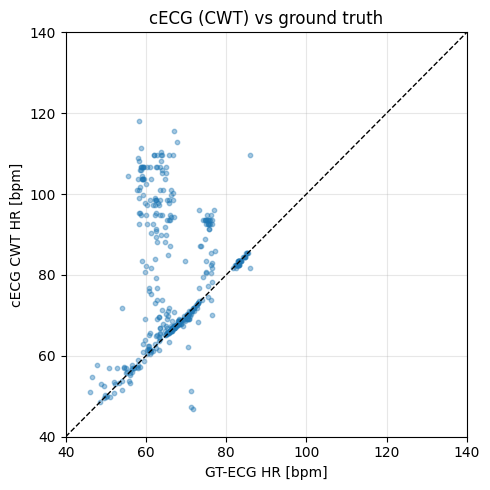

In [12]:
# === Track 3: cECG detector comparison vs ground-truth ECG ===

VAL_PATIENTS = 10         # neurokit2 is slow; a sample is enough
MAX_WIN_PER_PAT = 40

def _hr_from_detector(window, fs, detector):
    rr = F._rr_ms_from_detector(window, fs, detector)   # plausible RR [ms] or None
    return 60000.0/np.median(rr) if (rr is not None and len(rr) >= 4) else np.nan

def _hr_heartpy(window, fs):
    ibi_s, _ = D.hrv_heartpy_reason(window, fs)
    return (60.0/ibi_s) if (ibi_s and ibi_s > 0) else np.nan

DETECTORS = {
    'CWT-fixed (chosen)': lambda w: _hr_from_detector(w, FS, F.detect_peaks_cecg_cwt),
    'Pan-Tompkins':       lambda w: _hr_from_detector(w, FS, D.detect_peaks_pan_tompkins),
    'CWT-robust':         lambda w: _hr_from_detector(w, FS, D.detect_peaks_cecg_robust),
    'heartpy (old)':      lambda w: _hr_heartpy(w, FS),
}

rows = []
for pid in patients[:VAL_PATIENTS]:
    try:
        pat = PatientSignals(os.path.join(DATA_ROOT, pid))
        pat.filter_all(fs=FS); pat.offset_correction()
    except Exception:
        continue
    n_fen = (len(pat.cecg_filt) - WIN) // HOP + 1
    for i in range(min(n_fen, MAX_WIN_PER_PAT)):
        w_cecg = pat.cecg_filt[i*HOP : i*HOP + WIN]
        gt0    = i*HOP*FS_GT//FS
        w_gt   = pat.gt_ecg_filt[gt0 : gt0 + FENSTER_SEK*FS_GT]
        if len(w_gt) < FENSTER_SEK*FS_GT:
            continue
        try:
            hr_gt = _hr_gt_median_rr(w_gt, FS_GT)
        except Exception:
            continue
        if not np.isfinite(hr_gt):
            continue
        for name, fn in DETECTORS.items():
            rows.append({'detector': name, 'hr_est': fn(w_cecg), 'hr_gt': hr_gt})

dfd = pd.DataFrame(rows)
summary = []
for name, g in dfd.groupby('detector'):
    valid = g.dropna(subset=['hr_est'])
    err = (valid['hr_est'] - valid['hr_gt']).abs()
    summary.append({'detector': name,
                    'coverage_%':   round(100*len(valid)/len(g), 0),
                    'median_|dHR|': round(err.median(), 1) if len(err) else np.nan,
                    'pct_<=10bpm':  round(100*(err <= 10).mean(), 0) if len(err) else np.nan,
                    'pct_<=5bpm':   round(100*(err <= 5).mean(), 0)  if len(err) else np.nan})
sm = pd.DataFrame(summary).sort_values('median_|dHR|')
print(sm.to_string(index=False))
sm.to_csv(RESULTS_DIR+'detektorvergleich_vs_gt.csv', index=False)

# optional thesis figure: estimated vs true HR, the chosen detector
import matplotlib.pyplot as plt
gc = dfd[dfd.detector=='CWT-fixed (chosen)'].dropna(subset=['hr_est'])
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(gc['hr_gt'], gc['hr_est'], s=10, alpha=0.4)
lim = [40, 140]; ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('GT-ECG HR [bpm]'); ax.set_ylabel('cECG CWT HR [bpm]')
ax.set_title('cECG (CWT) vs ground truth'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR+'cecg_hr_vs_gt.png', dpi=130); plt.show()

In [13]:
rob = V.simulate_artifact_robustness(cecg_windows, FS, signal_type='cecg')
print(rob)   # injects spike artifacts into ~30% of windows and reports whether the composite SQI separates clean vs corrupted (trenn_auc)

Artefakt-Robustheit (cecg, 63 korrumpiert):
  composite-SQI  sauber=0.355  artefakt=0.294
  Trenn-AUC (SQI erkennt Artefakt): 0.767  (gut)
{'sqi_sauber_median': 0.3549008206630604, 'sqi_artefakt_median': 0.29383671163897035, 'trenn_auc': 0.7668253968253969, 'n_artefakt': 63}


## 3. Datensatz-Übersicht

=== Übersicht ===
Patienten:   40 (19 AF, 21 Non-AF)
Fenster:     4724  (AF 2257 / Non-AF 2467)
Features:    140
NaN-Anteil:  2.7%
SQI-Gewicht: mean 0.760  (min 0.449, max 0.897)


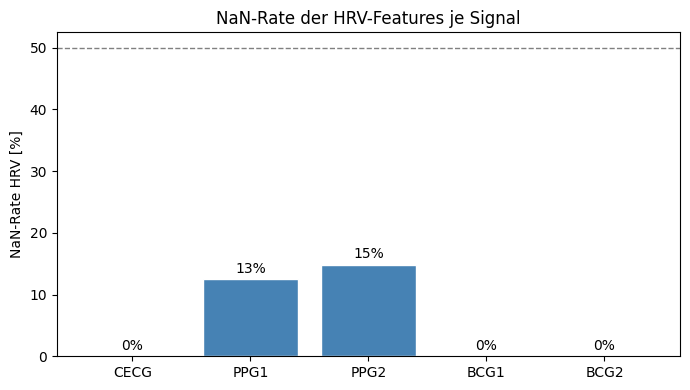

In [14]:
y      = df['AF'].astype(int).values
groups = df['patient'].values
w_sqi  = df['_window_sqi'].values
X_df = df.drop(columns=['patient','AF'] + [c for c in df.columns if c.startswith('_')])

print('=== Übersicht ===')
print(f'Patienten:   {len(np.unique(groups))} '
      f'({len(np.unique(groups[y==1]))} AF, {len(np.unique(groups[y==0]))} Non-AF)')
print(f'Fenster:     {len(df)}  (AF {y.sum()} / Non-AF {(1-y).sum()})')
print(f'Features:    {X_df.shape[1]}')
print(f'NaN-Anteil:  {X_df.isna().mean().mean()*100:.1f}%')
print(f'SQI-Gewicht: mean {w_sqi.mean():.3f}  (min {w_sqi.min():.3f}, max {w_sqi.max():.3f})')

# NaN-Raten der HRV-Features je Signal
fig, ax = plt.subplots(figsize=(7, 4))
hrv_keys = ['meanRR','SDNN','RMSSD','pNN50','SD1','SD2','SD1_SD2']
rates = []
for s in SIGNALS:
    cols = [f'{s}_{k}' for k in hrv_keys if f'{s}_{k}' in X_df.columns]
    rates.append(X_df[cols].isna().any(axis=1).mean()*100)
ax.bar([s.upper() for s in SIGNALS], rates, color='steelblue', edgecolor='white')
ax.set_ylabel('NaN-Rate HRV [%]'); ax.set_title('NaN-Rate der HRV-Features je Signal')
ax.axhline(50, color='gray', ls='--', lw=1)
for i, r in enumerate(rates):
    ax.text(i, r+1, f'{r:.0f}%', ha='center')
plt.tight_layout(); plt.savefig(RESULTS_DIR+'nan_raten.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Feature-Selektion (RandomForest-Importance ≥ 0.008)

140 Features (Selektion erfolgt pro Fold in der Pipeline)


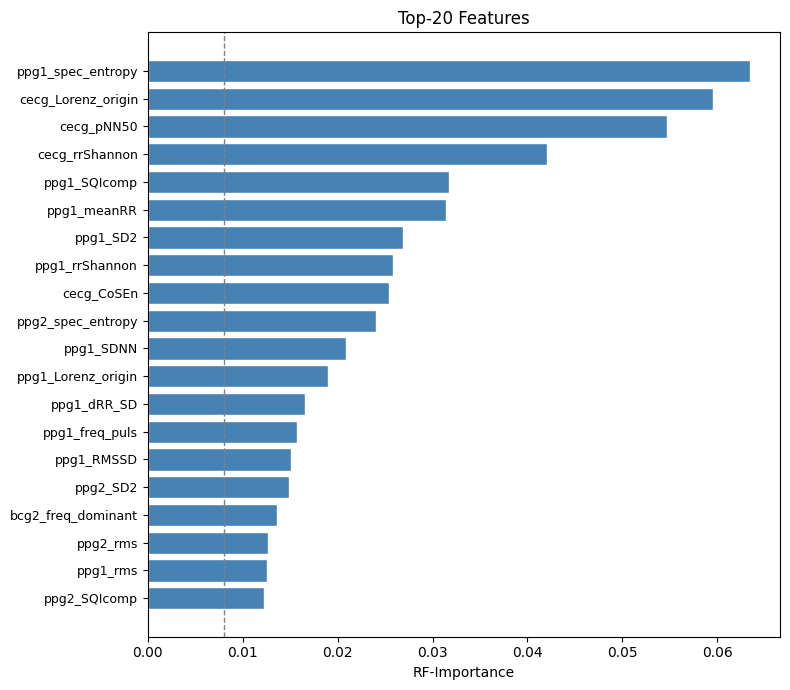

In [15]:
_, imp = M.select_features_rf(X_df.values, y, threshold=0.008)   # nur für den Plot
X_sel = X_df.values            # alle Features; Selektion passiert leak-frei in der Pipeline
print(f'{X_df.shape[1]} Features (Selektion erfolgt pro Fold in der Pipeline)')

order = np.argsort(imp)[::-1][:20]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(np.arange(20)[::-1], imp[order], color='steelblue', edgecolor='white')
ax.set_yticks(np.arange(20)[::-1]); ax.set_yticklabels(np.array(X_df.columns)[order], fontsize=9)
ax.axvline(0.008, color='gray', ls='--', lw=1)
ax.set_xlabel('RF-Importance'); ax.set_title('Top-20 Features')
plt.tight_layout(); plt.savefig(RESULTS_DIR+'feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

130 failure windows found; plotting first 8


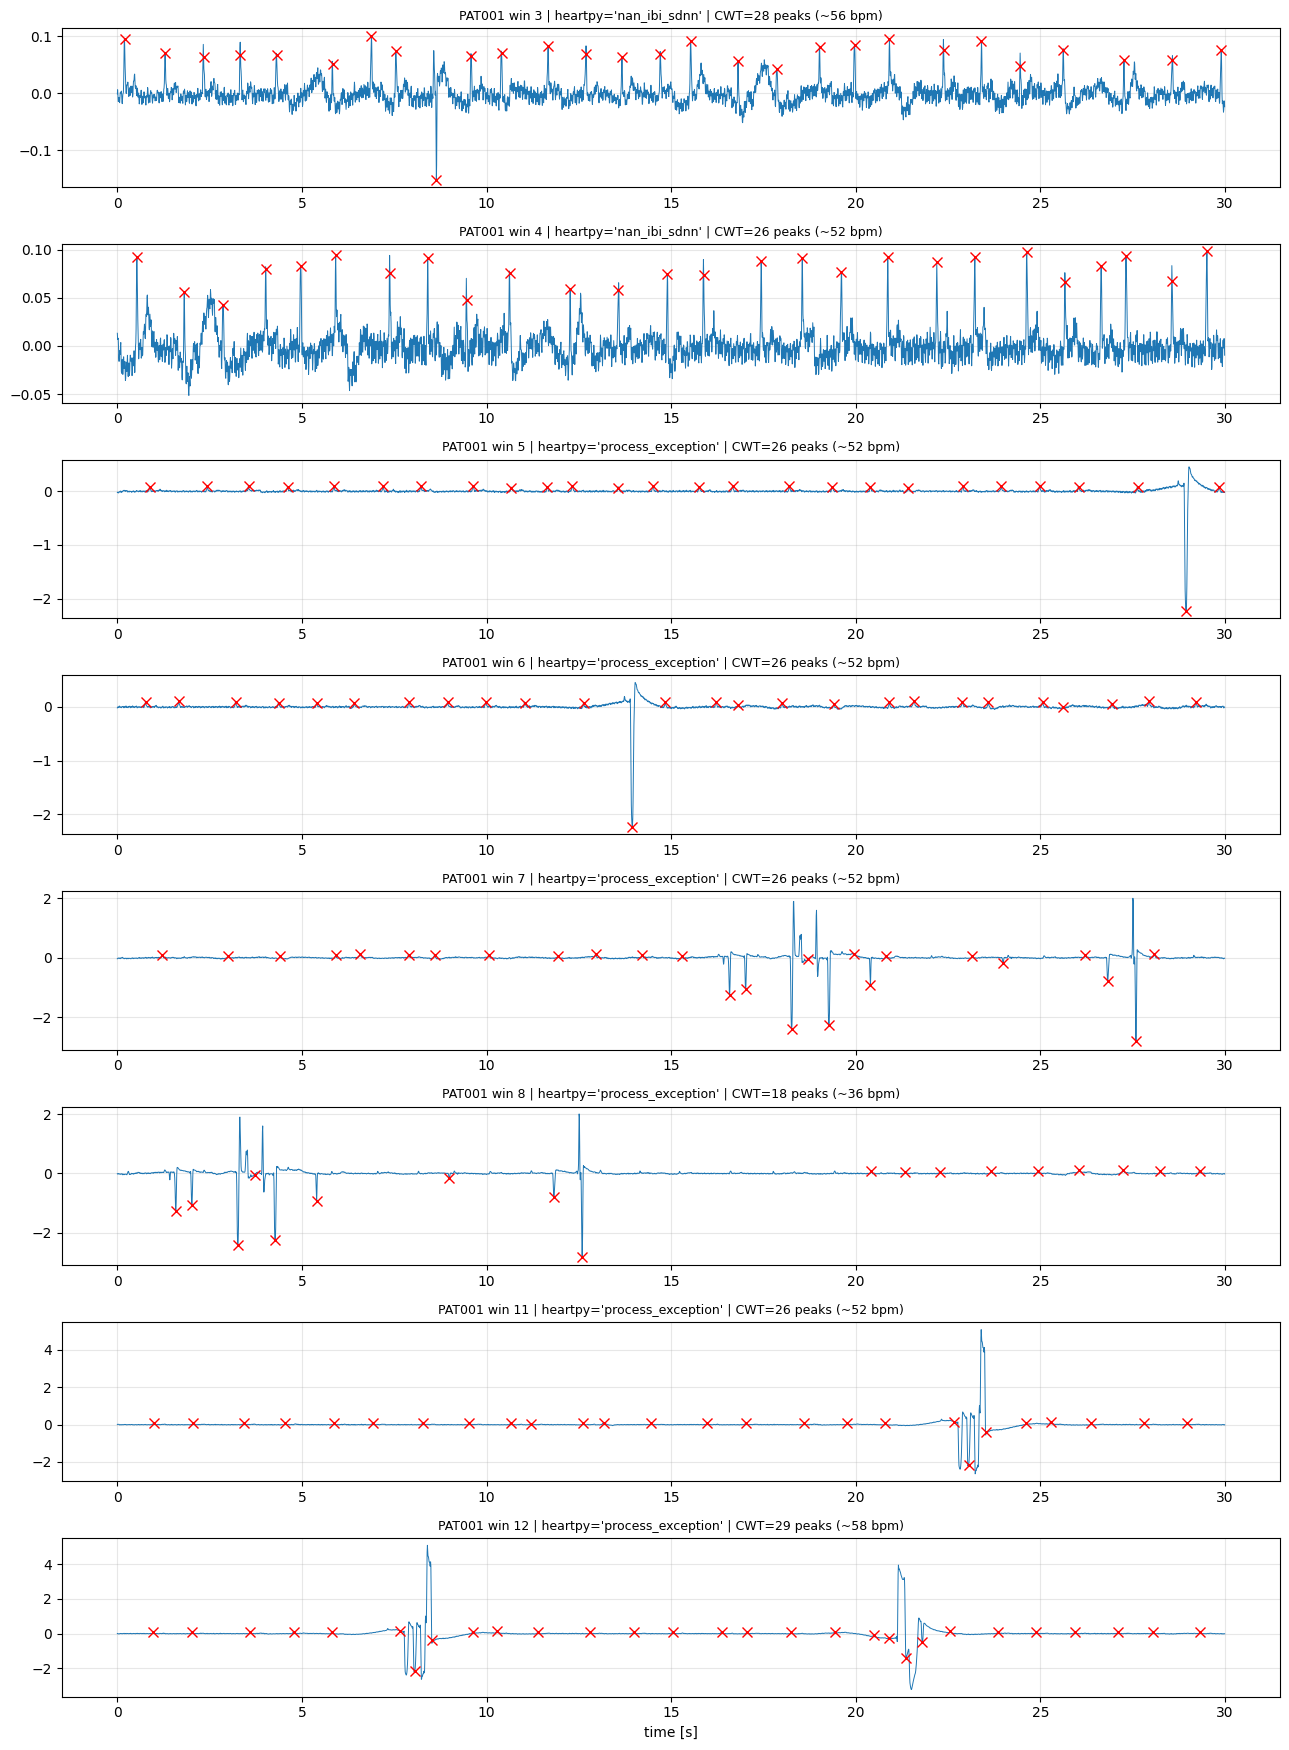

In [16]:
# === CELL 7c: visually inspect heartpy-failure windows (cECG) ===

INSPECT_PATIENTS = 2      # keep small; plotting is the slow part
TARGET_REASONS = ('process_exception', 'nan_ibi_sdnn')  # the two dominant failures
MAX_PLOTS = 8

bad = []   # (pid, window_index, reason, window_array)
for pid in patients[:INSPECT_PATIENTS]:
    pat = PatientSignals(os.path.join(DATA_ROOT, pid))
    pat.filter_all(fs=FS); pat.offset_correction()
    n_fen = (len(pat.cecg_filt) - WIN) // HOP + 1
    for i in range(n_fen):
        w = pat.cecg_filt[i*HOP : i*HOP + WIN]
        _, reason = D.hrv_heartpy_reason(w, FS)
        if reason in TARGET_REASONS:
            bad.append((pid, i, reason, w))

print(f'{len(bad)} failure windows found; plotting first {min(MAX_PLOTS,len(bad))}')
show = bad[:MAX_PLOTS]
if show:
    fig, axs = plt.subplots(len(show), 1, figsize=(13, 2.2*len(show)), squeeze=False)
    t = np.arange(WIN) / FS
    for ax, (pid, i, reason, w) in zip(axs[:,0], show):
        ax.plot(t, w, lw=0.7)
        pk = F.detect_peaks_cecg_cwt(w, FS)          # the fixed CWT detector
        pk = pk[(pk >= 0) & (pk < WIN)]
        ax.plot(pk/FS, np.asarray(w)[pk], 'rx', ms=7)
        bpm = len(pk) * (60.0 / FENSTER_SEK)
        ax.set_title(f"{pid} win {i} | heartpy='{reason}' | CWT={len(pk)} peaks (~{bpm:.0f} bpm)", fontsize=9)
        ax.grid(alpha=0.3)
    axs[-1,0].set_xlabel('time [s]')
    plt.tight_layout(); plt.savefig(RESULTS_DIR + 'cecg_heartpy_failures.png', dpi=110); plt.show()

## 5. Modellvergleich
Fünf Modelle (SVM, LR, RF, GB, **XGBoost**) in mehreren Modi:
- `window` – fensterbasiert (Baseline)
- `mv_pooled` – Patientenebene, alter Threshold (optimistisch)
- `mv_nested` – Patientenebene, leckagefreier Threshold
- `mv_nested_sqi` – wie nested, aber **SQI-gewichtete Fusion**

Der `mv_nested`-Pfad ist langsamer (innere CV pro Fold).

In [17]:
# === parallel compare_models — identical numbers to M.compare_models, all 5 modes ===
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
from joblib import Parallel, delayed, parallel_config

def _f_window(tr, te, pipe, X, y):
    p = clone(pipe).fit(X[tr], y[tr])
    return y[te], p.predict_proba(X[te])[:, 1], p.predict(X[te])

def _f_window_nested(tr, te, pipe, X, y, groups, min_spec, inner_splits, rs):
    Xtr, ytr, gtr = X[tr], y[tr], groups[tr]; n_in = min(inner_splits, len(np.unique(gtr)))
    cv = StratifiedGroupKFold(n_splits=n_in, shuffle=True, random_state=rs); iyt, iyp = [], []
    for itr, ite in cv.split(Xtr, ytr, gtr):
        q = clone(pipe).fit(Xtr[itr], ytr[itr]); iyp.extend(q.predict_proba(Xtr[ite])[:, 1]); iyt.extend(ytr[ite])
    t = M.choose_threshold(np.array(iyt), np.array(iyp), min_spec)
    p = clone(pipe).fit(Xtr, ytr); yp = p.predict_proba(X[te])[:, 1]
    return y[te], yp, (yp >= t).astype(int), t, len(te)

def _f_patient_prob(tr, te, pipe, X, y, wsqi, min_sqi):
    p = clone(pipe).fit(X[tr], y[tr]); w = None if wsqi is None else wsqi[te]
    return int(y[te][0]), float(M._agg_patient(p.predict_proba(X[te])[:, 1], w, min_sqi))

def _f_mv_nested(tr, te, pipe, X, y, groups, min_spec, inner_splits, rs, wsqi, min_sqi):
    q = clone(pipe); wtr = None if wsqi is None else wsqi[tr]
    it, ip = M._inner_patient_probs(q, X[tr], y[tr], groups[tr], window_sqi=wtr, min_sqi=min_sqi,
                                    n_splits=inner_splits, random_state=rs)
    t = M.choose_threshold(it, ip, min_spec); q.fit(X[tr], y[tr]); wte = None if wsqi is None else wsqi[te]
    return int(y[te][0]), float(M._agg_patient(q.predict_proba(X[te])[:, 1], wte, min_sqi)), float(t)

def _eval_parallel(mode, pipe, X, y, groups, min_spec, inner_splits, rs, wsqi, min_sqi, n_jobs):
    sp = list(LeaveOneGroupOut().split(X, y, groups))
    with parallel_config(backend='loky', n_jobs=n_jobs, inner_max_num_threads=1):
        if mode == 'window':
            o = Parallel()(delayed(_f_window)(tr, te, pipe, X, y) for tr, te in sp)
            yt = np.concatenate([a for a,_,_ in o]); yp = np.concatenate([b for _,b,_ in o]); yd = np.concatenate([c for _,_,c in o])
            return M.metrics(yt, yp, yd), 0.5
        if mode == 'window_nested':
            o = Parallel()(delayed(_f_window_nested)(tr, te, pipe, X, y, groups, min_spec, inner_splits, rs) for tr, te in sp)
            yt = np.concatenate([a for a,_,_,_,_ in o]); yp = np.concatenate([b for _,b,_,_,_ in o]); yd = np.concatenate([c for _,_,c,_,_ in o])
            ts = np.array([t for _,_,_,t,n in o for _ in range(n)]); return M.metrics(yt, yp, yd), float(ts.mean())
        if mode in ('mv_pooled', 'mv_pooled_sqi'):
            w = wsqi if mode.endswith('sqi') else None
            o = Parallel()(delayed(_f_patient_prob)(tr, te, pipe, X, y, w, min_sqi) for tr, te in sp)
            true = np.array([a for a,_ in o]); prob = np.array([b for _,b in o]); t = M.choose_threshold(true, prob, min_spec)
            return M.metrics(true, prob, (prob >= t).astype(int)), t
        if mode in ('mv_nested', 'mv_nested_sqi'):
            w = wsqi if mode.endswith('sqi') else None
            o = Parallel()(delayed(_f_mv_nested)(tr, te, pipe, X, y, groups, min_spec, inner_splits, rs, w, min_sqi) for tr, te in sp)
            true = np.array([a for a,_,_ in o]); prob = np.array([b for _,b,_ in o]); tt = np.array([c for _,_,c in o])
            return M.metrics(true, prob, (prob >= tt).astype(int)), float(tt.mean())
        raise ValueError(mode)

def compare_models_parallel(X, y, groups, balanced=True,
                            modes=('window','window_nested','mv_pooled','mv_nested','mv_nested_sqi'),
                            min_spec=M.TARGET_SPEC, window_sqi=None, min_sqi=0.0, n_jobs=-1):
    X = np.asarray(X, float); y = np.asarray(y).astype(int); groups = np.asarray(groups)
    if window_sqi is not None: window_sqi = np.asarray(window_sqi, float)
    spw = max(1, int((1 - y).sum())) / max(1, int(y.sum()))
    rows = []
    for name in M.MODEL_ORDER:
        for mode in modes:
            pipe = M.make_pipelines(balanced=balanced, scale_pos_weight=spw)[name]
            m, t = _eval_parallel(mode, pipe, X, y, groups, min_spec, 5, M.RANDOM_STATE, window_sqi, min_sqi, n_jobs)
            rows.append({'Modell': name, 'Modus': mode, 'Accuracy': m['Accuracy'], 'AUC': m['AUC'],
                         'Sensitivität': m['Sensitivität'], 'Spezifität': m['Spezifität'], 'Threshold': t})
    return pd.DataFrame(rows)

In [18]:
import hashlib, json, joblib
CACHE_MODELS = '../results/_modelcache/'; os.makedirs(CACHE_MODELS, exist_ok=True)

def _arrhash(*objs):
    h = hashlib.sha1()
    for o in objs:
        if isinstance(o, np.ndarray): h.update(np.ascontiguousarray(o).tobytes()); h.update(str(o.shape).encode())
        else: h.update(json.dumps(o, sort_keys=True, default=str).encode())
    h.update(str(os.path.getmtime(M.__file__)).encode())   # auto-invalidate if models.py changes
    return h.hexdigest()[:16]

def cached_compare_models(X, y, groups, tag, **kw):
    key = _arrhash(X, y, groups, kw.get('window_sqi'), tag, kw.get('modes'),
                   kw.get('min_sqi', 0.0), kw.get('balanced', True))
    fp = os.path.join(CACHE_MODELS, f'res_{tag}_{key}.pkl')
    if os.path.exists(fp): print('[cache HIT]', os.path.basename(fp)); return joblib.load(fp)
    print('[cache MISS] computing ...'); res = compare_models_parallel(X, y, groups, **kw, n_jobs=8)
    joblib.dump(res, fp); return res

In [19]:
res = cached_compare_models(
    X_sel, y, groups, tag=CECG_TAG, balanced=True,
    modes=('window', 'window_nested', 'mv_pooled', 'mv_nested', 'mv_nested_sqi'),
    window_sqi=w_sqi, min_sqi=0.0)

fmt = {c: '{:.3f}'.format for c in ['Accuracy','AUC','Sensitivität','Spezifität','Threshold']}
res_sorted = res.sort_values(['Modus','AUC'], ascending=[True, False])
print(res_sorted.to_string(index=False, formatters=fmt))
res.to_csv(RESULTS_DIR+'modellvergleich.csv', index=False)

best = res.loc[res['AUC'].idxmax()]
print(f"\nBestes Modell nach AUC: {best['Modell']} / {best['Modus']}  "
      f"AUC={best['AUC']:.3f}  Sens={best['Sensitivität']:.3f}  Spez={best['Spezifität']:.3f}")

print('\nRobustheitsgewinn durch SQI-Gewichtung (nested):')
for metric in ['Accuracy','AUC','Sensitivität','Spezifität']:
    a = res[res.Modus=='mv_nested'][metric].mean()
    b = res[res.Modus=='mv_nested_sqi'][metric].mean()
    arrow = '↑' if b>a+1e-9 else ('=' if abs(b-a)<=1e-9 else '↓')
    print(f'  {metric:14s} {a:.3f} -> {b:.3f}  {arrow}')

[cache MISS] computing ...
Modell         Modus Accuracy   AUC Sensitivität Spezifität Threshold
    LR     mv_nested    0.925 0.975        1.000      0.857     0.415
   SVM     mv_nested    0.925 0.970        0.947      0.905     0.373
    RF     mv_nested    0.725 0.910        0.684      0.762     0.515
   XGB     mv_nested    0.750 0.905        0.737      0.762     0.485
    GB     mv_nested    0.700 0.900        0.684      0.714     0.477
    LR mv_nested_sqi    0.925 0.975        1.000      0.857     0.418
   SVM mv_nested_sqi    0.950 0.970        1.000      0.905     0.359
    RF mv_nested_sqi    0.725 0.910        0.684      0.762     0.513
   XGB mv_nested_sqi    0.750 0.905        0.737      0.762     0.485
    GB mv_nested_sqi    0.725 0.900        0.684      0.762     0.467
    LR     mv_pooled    0.925 0.975        1.000      0.857     0.430
   SVM     mv_pooled    0.925 0.970        1.000      0.857     0.303
    RF     mv_pooled    0.875 0.910        0.789      0.952    

In [20]:
# ── Bestes Modell je deployment-relevantem Modus (KEIN pooled) ──
print('\n── Bestes Modell je Modus (ohne pooled) ──')
for modus in ['window_nested', 'mv_nested', 'mv_nested_sqi']:
    sub = res[res.Modus == modus]
    if sub.empty: continue
    b = sub.sort_values('AUC', ascending=False).iloc[0]
    print(f"  {modus:15s}: {b['Modell']:4s}  AUC={b['AUC']:.3f}  "
          f"Sens={b['Sensitivität']:.3f}  Spez={b['Spezifität']:.3f}")


── Bestes Modell je Modus (ohne pooled) ──
  window_nested  : LR    AUC=0.942  Sens=0.924  Spez=0.783
  mv_nested      : LR    AUC=0.975  Sens=1.000  Spez=0.857
  mv_nested_sqi  : LR    AUC=0.975  Sens=1.000  Spez=0.857


## 6. Plots: ROC & Metrikvergleich

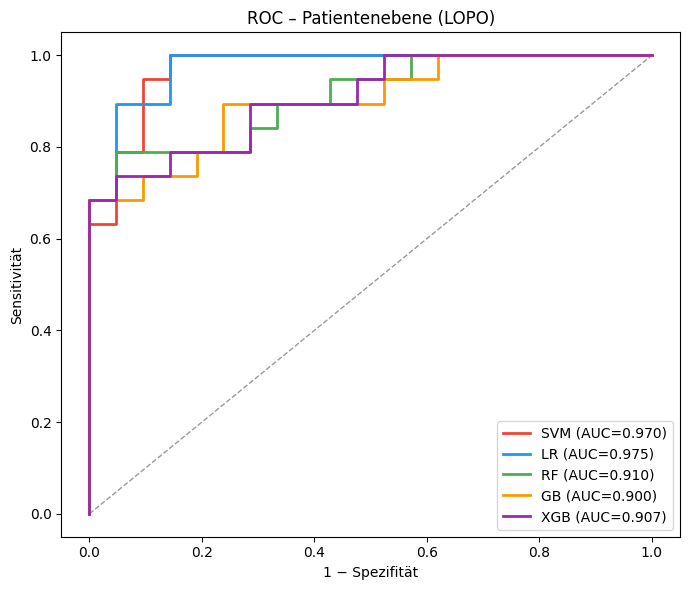

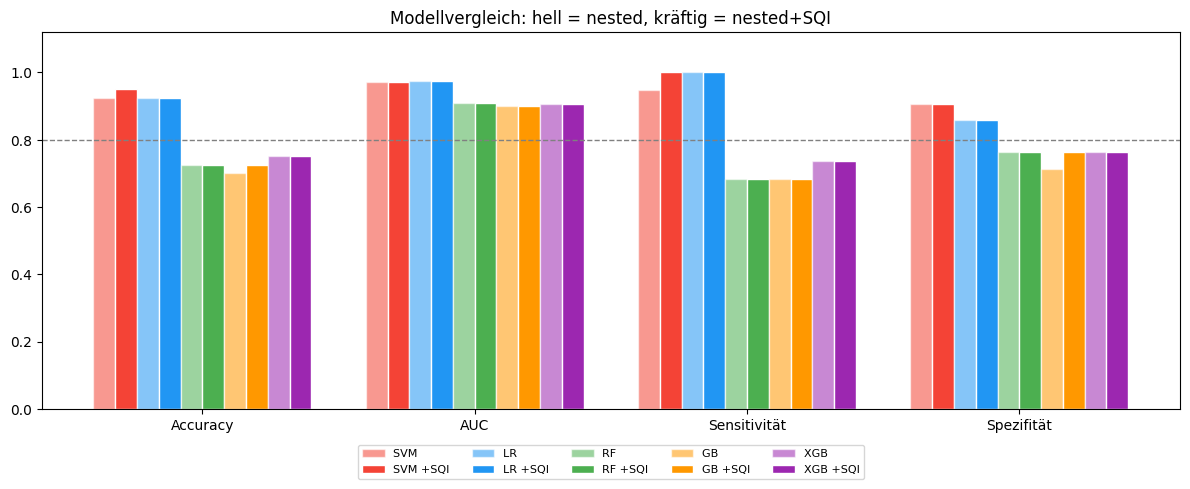

In [21]:
from sklearn.metrics import roc_curve, auc as sk_auc

MODELS = M.MODEL_ORDER   # enthält XGB automatisch, falls installiert
COLORS = {'SVM':'#F44336','LR':'#2196F3','RF':'#4CAF50','GB':'#FF9800','XGB':'#9C27B0'}

# ROC-Kurven (nested, ungewichtet) für alle Modelle
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
for name in MODELS:
    pipe = M.make_pipelines(balanced=True)[name]
    _, true, prob = M.lopo_patient_probs(pipe, X_sel, y, groups)
    fpr, tpr, _ = roc_curve(true, prob)
    ax.plot(fpr, tpr, color=COLORS.get(name,'#555'), lw=2,
            label=f'{name} (AUC={sk_auc(fpr,tpr):.3f})')
ax.set_xlabel('1 − Spezifität'); ax.set_ylabel('Sensitivität')
ax.set_title('ROC – Patientenebene (LOPO)'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(RESULTS_DIR+'roc.png', dpi=150, bbox_inches='tight'); plt.show()

# Metrikvergleich Balken (nested vs nested+SQI)
metr = ['Accuracy','AUC','Sensitivität','Spezifität']
modi = ['mv_nested','mv_nested_sqi']
n_mod = len(MODELS)
fig, ax = plt.subplots(figsize=(12,5))
xpos = np.arange(len(metr)); width = 0.8/(n_mod*len(modi))
for mi, name in enumerate(MODELS):
    for di, modus in enumerate(modi):
        sub = res[(res.Modell==name)&(res.Modus==modus)]
        if sub.empty: continue
        r = sub.iloc[0]; vals = [r[m] for m in metr]
        offset = (mi*len(modi)+di - (n_mod*len(modi))/2 + 0.5)*width
        ax.bar(xpos+offset, vals, width, color=COLORS.get(name,'#555'),
               alpha=0.55 if di==0 else 1.0, edgecolor='white',
               label=f'{name} {"+SQI" if di else ""}' if mi<99 else None)
ax.set_xticks(xpos); ax.set_xticklabels(metr); ax.set_ylim(0,1.12)
ax.axhline(0.8, color='gray', ls='--', lw=1)
ax.set_title('Modellvergleich: hell = nested, kräftig = nested+SQI')
ax.legend(ncol=n_mod, fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-0.08))
plt.tight_layout(); plt.savefig(RESULTS_DIR+'metrikvergleich.png', dpi=150, bbox_inches='tight'); plt.show()

Bestes mv_nested-Modell: LR  |  bestes window_nested-Modell: LR


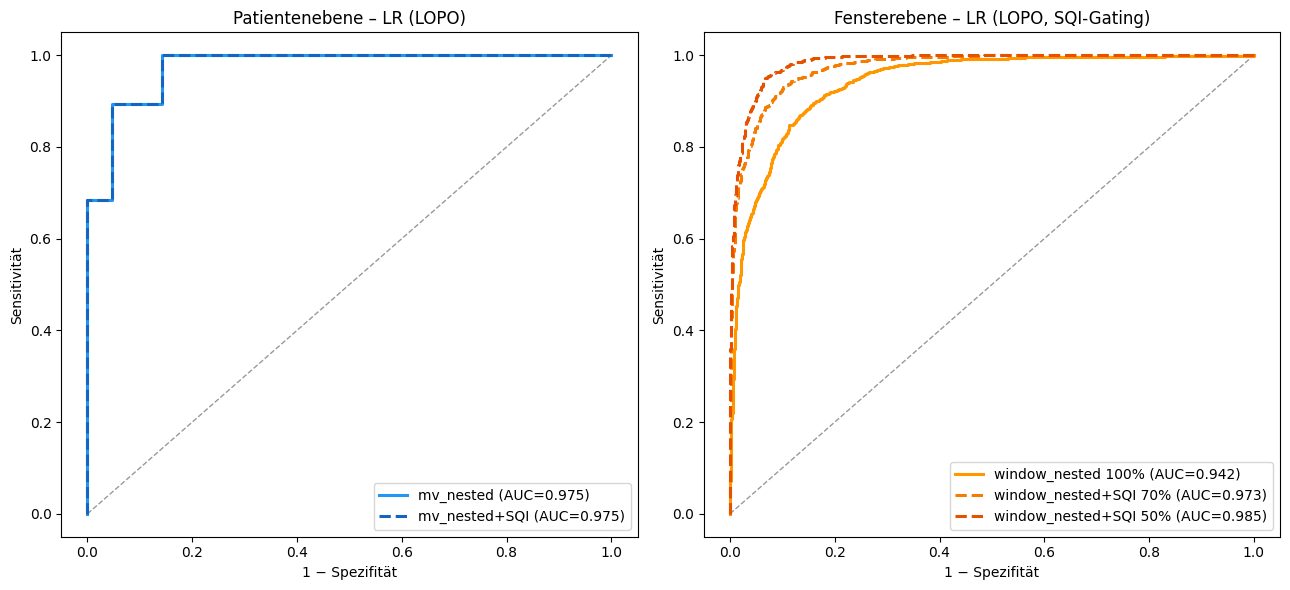

In [22]:
# === ROC: Patientenebene (mv_nested ± SQI) & Fensterebene (window_nested ± SQI-Gating) — KEIN pooled ===
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.model_selection import LeaveOneGroupOut

best_mv  = res[res.Modus=='mv_nested'].sort_values('AUC', ascending=False).iloc[0]['Modell']
best_win = res[res.Modus=='window_nested'].sort_values('AUC', ascending=False).iloc[0]['Modell']
print(f"Bestes mv_nested-Modell: {best_mv}  |  bestes window_nested-Modell: {best_win}")

def _window_oof(pipe, X, y, groups, wsqi):
    logo = LeaveOneGroupOut(); yt, yp, order = [], [], []
    for tr, te in logo.split(X, y, groups):
        pipe.fit(X[tr], y[tr]); yp.extend(pipe.predict_proba(X[te])[:, 1])
        yt.extend(y[te]); order.extend(te)
    return np.array(yt), np.array(yp), np.asarray(wsqi)[np.array(order)]

fig, (axP, axW) = plt.subplots(1, 2, figsize=(13, 6))

# --- Patientenebene: mv_nested vs mv_nested+SQI ---
axP.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
p = M.make_pipelines(balanced=True)[best_mv]
_, tu, pu = M.lopo_patient_probs(p, X_sel, y, groups)
f,t,_ = roc_curve(tu, pu); axP.plot(f,t,lw=2.2,color='#2196F3',
        label=f'mv_nested (AUC={sk_auc(f,t):.3f})')
p = M.make_pipelines(balanced=True)[best_mv]
_, tw, pw = M.lopo_patient_probs(p, X_sel, y, groups, window_sqi=w_sqi)
f,t,_ = roc_curve(tw, pw); axP.plot(f,t,lw=2.2,color='#1565C0',ls='--',
        label=f'mv_nested+SQI (AUC={sk_auc(f,t):.3f})')
axP.set_title(f'Patientenebene – {best_mv} (LOPO)')
axP.set_xlabel('1 − Spezifität'); axP.set_ylabel('Sensitivität'); axP.legend(loc='lower right')

# --- Fensterebene: window_nested voll vs SQI-gated ---
axW.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
p = M.make_pipelines(balanced=True)[best_win]
yt, yp, sqi = _window_oof(p, X_sel, y, groups, w_sqi)
f,t,_ = roc_curve(yt, yp); axW.plot(f,t,lw=2.2,color='#FF9800',
        label=f'window_nested 100% (AUC={sk_auc(f,t):.3f})')
for cov, col in [(0.7,'#F57C00'), (0.5,'#E65100')]:
    th = np.quantile(sqi, 1-cov); m = sqi >= th
    f,t,_ = roc_curve(yt[m], yp[m])
    axW.plot(f,t,lw=2.2,color=col,ls='--',
             label=f'window_nested+SQI {int(cov*100)}% (AUC={sk_auc(f,t):.3f})')
axW.set_title(f'Fensterebene – {best_win} (LOPO, SQI-Gating)')
axW.set_xlabel('1 − Spezifität'); axW.set_ylabel('Sensitivität'); axW.legend(loc='lower right')

plt.tight_layout(); plt.savefig(RESULTS_DIR+'roc_mv_window_sqi.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Bootstrap-Konfidenzintervalle (bestes Modell)

In [23]:
best_name = best['Modell']
pipe = M.make_pipelines(balanced=True)[best_name]
_, true, prob = M.lopo_patient_probs(pipe, X_sel, y, groups)
t = M.choose_threshold(true, prob, min_spec=0.80)
ci = M.bootstrap_ci(true, prob, t, n_boot=2000)
print(f'95%-Konfidenzintervalle ({best_name}, nested-Threshold t={t:.3f}):')
for k,(lo,hi) in ci.items():
    print(f'  {k:14s} [{lo:.3f}, {hi:.3f}]')
    
pipe = M.make_pipelines(balanced=True)[best_name]
yt_all, yp_all, groups_all = [], [], []
logo = LeaveOneGroupOut()
for tr, te in logo.split(X_sel, y, groups):
    pipe.fit(X_sel[tr], y[tr])
    yp_all.extend(pipe.predict_proba(X_sel[te])[:,1])
    yt_all.extend(y[te])
    groups_all.extend(groups[te])

# Fensterebene: OOF-Probs des besten Modells + Cluster-(patientenweiser)-Bootstrap
best_t = float(res[(res.Modell == best_name) & (res.Modus == 'window_nested')]['Threshold'].iloc[0])
pipe = M.make_pipelines(balanced=True)[best_name]
yt_all, yp_all, groups_all = [], [], []
logo = LeaveOneGroupOut()
for tr, te in logo.split(X_sel, y, groups):
    pipe.fit(X_sel[tr], y[tr])
    yp_all.extend(pipe.predict_proba(X_sel[te])[:, 1])
    yt_all.extend(y[te]); groups_all.extend(groups[te])

ci_w = M.bootstrap_ci(np.array(yt_all), np.array(yp_all),
                      threshold=best_t, n_boot=2000, groups=np.array(groups_all))
print(f'\n95%-CIs Fensterebene, Cluster-Bootstrap ({best_name}, window_nested t={best_t:.3f}):')
for k, (lo, hi) in ci_w.items():
    print(f'  {k:14s} [{lo:.3f}, {hi:.3f}]')

95%-Konfidenzintervalle (LR, nested-Threshold t=0.430):
  Accuracy       [0.825, 1.000]
  AUC            [0.928, 1.000]
  Sensitivität   [1.000, 1.000]
  Spezifität     [0.684, 1.000]

95%-CIs Fensterebene, Cluster-Bootstrap (LR, window_nested t=0.311):
  Accuracy       [0.791, 0.918]
  AUC            [0.891, 0.978]
  Sensitivität   [0.859, 0.973]
  Spezifität     [0.683, 0.902]


## 8. (Optional) SQI-Validierung gegen GT-EKG
Zeigt, dass Fenster mit hohem SQI kleinere HR-Fehler gegen das GT-EKG haben.
**Wichtig:** Das GT-EKG validiert hier nur den SQI – es geht nicht in dessen
Berechnung ein. Benötigt `neurokit2` für die GT-HR.

In [24]:
# Optional – auskommentiert lassen, wenn neurokit2 nicht installiert ist.
# import neurokit2 as nk
# from signal_loader import PatientSignals
# rows_val = []
# with open(AF_LIST) as f: af = [l.strip() for l in f if l.strip()]
# for pid in sorted(os.listdir(DATA_ROOT))[:10]:   # Stichprobe
#     try:
#         pat = PatientSignals(os.path.join(DATA_ROOT, pid)); pat.filter_all(fs=FS); pat.offset_correction()
#     except: continue
#     n_fen = (len(pat.ppg1_filt) - WIN)//HOP + 1
#     for i in range(n_fen):
#         w_ppg = pat.ppg1_filt[i*HOP:i*HOP+WIN]
#         w_gt  = pat.gt_ecg_filt[i*HOP*FS_GT//FS : i*HOP*FS_GT//FS + FENSTER_SEK*FS_GT]
#         hr_est = Q.estimate_hr_peaks(w_ppg, FS)
#         try: hr_gt = nk.ecg_process(w_gt, sampling_rate=FS_GT)[0]['ECG_Rate'].mean()
#         except: hr_gt = np.nan
#         comp = Q.signal_sqi(w_ppg, FS, 'ppg')['composite']
#         rows_val.append({'sqi': comp, 'err': abs(hr_est-hr_gt)})
# dv = pd.DataFrame(rows_val).dropna()
# hi = dv[dv.sqi >= dv.sqi.median()]; lo = dv[dv.sqi < dv.sqi.median()]
# print(f'HR-Fehler |Δbpm|:  hoher SQI = {hi.err.median():.1f}   niedriger SQI = {lo.err.median():.1f}')
print('SQI-Validierung: Zelle bei Bedarf einkommentieren (neurokit2 nötig).')

SQI-Validierung: Zelle bei Bedarf einkommentieren (neurokit2 nötig).


## 9 Validierung

In [25]:
# After a heartpy run:  res.to_csv(RESULTS_DIR+'modellvergleich_heartpy.csv')
# After the CWT run:    res.to_csv(RESULTS_DIR+'modellvergleich_cwt.csv')
import pandas as pd
a = pd.read_csv(RESULTS_DIR+'modellvergleich_heartpy.csv')
b = pd.read_csv(RESULTS_DIR+'modellvergleich_cwt.csv')
key = ['Modell','Modus']
cmp = a.merge(b, on=key, suffixes=('_hp','_cwt'))
for m in ['AUC','Sensitivität','Spezifität']:
    cmp[m+'_Δ'] = cmp[m+'_cwt'] - cmp[m+'_hp']
print(cmp[key + [c for c in cmp.columns if c.endswith('_Δ')]].to_string(index=False))

Modell         Modus     AUC_Δ  Sensitivität_Δ  Spezifität_Δ
   SVM        window -0.000417        0.009659      0.006122
   SVM window_nested -0.000417       -0.009885      0.008078
   SVM     mv_pooled  0.002506        0.000000      0.000000
   SVM     mv_nested  0.002506        0.000000     -0.047619
   SVM mv_nested_sqi  0.002506        0.000000     -0.047619
    LR        window -0.008816       -0.009017     -0.015303
    LR window_nested -0.008816        0.012377     -0.026921
    LR     mv_pooled -0.005013        0.000000     -0.047619
    LR     mv_nested -0.005013        0.052632     -0.047619
    LR mv_nested_sqi -0.002506        0.052632     -0.047619
    RF        window -0.011637       -0.007638      0.000058
    RF window_nested -0.011637       -0.009417      0.030493
    RF     mv_pooled  0.007519        0.000000      0.142857
    RF     mv_nested  0.007519        0.000000      0.095238
    RF mv_nested_sqi  0.007519        0.000000      0.095238
    GB        window -0.

What is each signal worth?

In [26]:
# === per-modality ablation ===
MODALITIES = {
    'cECG only':  ['cecg'],
    'PPG only':   ['ppg1','ppg2'],
    'BCG only':   ['bcg1','bcg2'],
    'PPG+BCG':    ['ppg1','ppg2','bcg1','bcg2'],
    'all (fusion)': SIGNALS,
}
def cols_for(prefixes):
    return [c for c in X_df.columns if any(c.startswith(p) for p in prefixes)]

abl = []
for name, prefs in MODALITIES.items():
    cols = cols_for(prefs)
    Xsub = X_df[cols].values
    m_sub, _ = M.select_features_rf(Xsub, y, threshold=0.008)
    if m_sub.sum() == 0:
        abl.append({'Modalität': name, 'n_features': 0, 'Modell': '—',
                    'AUC': float('nan'), 'Sens': float('nan'), 'Spez': float('nan')})
        continue
    Xsel_sub = Xsub[:, m_sub]
    r = compare_models_parallel(Xsel_sub, y, groups, balanced=True, modes=('mv_nested',), window_sqi=w_sqi, min_sqi=0.0, n_jobs=8)
    best = r.loc[r['AUC'].idxmax()]
    abl.append({'Modalität': name, 'n_features': int(m_sub.sum()),
                'Modell': best['Modell'], 'AUC': best['AUC'],
                'Sens': best['Sensitivität'], 'Spez': best['Spezifität']})
import pandas as pd
abl_df = pd.DataFrame(abl)
print(abl_df.to_string(index=False))
abl_df.to_csv(RESULTS_DIR+'ablation_modalitaeten.csv', index=False)


   Modalität  n_features Modell      AUC     Sens     Spez
   cECG only          28     GB 0.904762 0.684211 0.857143
    PPG only          38     LR 0.982456 0.894737 0.809524
    BCG only          40     GB 0.812030 0.473684 0.904762
     PPG+BCG          40    SVM 0.957393 0.842105 0.857143
all (fusion)          35    SVM 0.977444 0.947368 0.857143


In [27]:
# === BCG detector validation vs GT ECG (Track 3 for BCG), split by rhythm ===
VAL_PATIENTS, MAX_WIN_PER_PAT, BCG_CH = 40, 40, 'bcg1'   # repeat with 'bcg2' if you like
with open(AF_LIST) as f:
    af_set = set(l.strip() for l in f if l.strip())

def _hr(window, fs, detector):
    rr = F._rr_ms_from_detector(window, fs, detector)      # cv_max=None
    return 60000.0 / np.median(rr) if (rr is not None and len(rr) >= 4) else np.nan

DETECTORS = {
    'BCG-CWT v2 (band+thr)': lambda w: _hr(w, FS, F.detect_peaks_bcg_cwt_v2),
    'BCG-CWT old (1 scale)': lambda w: _hr(w, FS, F.detect_peaks_bcg_cwt),
}

rows = []
for pid in patients[:VAL_PATIENTS]:
    try:
        pat = PatientSignals(os.path.join(DATA_ROOT, pid)); pat.filter_all(fs=FS); pat.offset_correction()
    except Exception:
        continue
    sig = getattr(pat, f'{BCG_CH}_filt'); n_fen = (len(sig) - WIN) // HOP + 1
    for i in range(min(n_fen, MAX_WIN_PER_PAT)):
        w_bcg = sig[i*HOP : i*HOP + WIN]
        gt0 = i*HOP*FS_GT//FS
        w_gt = pat.gt_ecg_filt[gt0 : gt0 + FENSTER_SEK*FS_GT]
        if len(w_gt) < FENSTER_SEK*FS_GT:
            continue
        try:
            hr_gt = nk.ecg_process(w_gt, sampling_rate=FS_GT)[0]['ECG_Rate'].mean()
        except Exception:
            continue
        if not np.isfinite(hr_gt):
            continue
        for name, fn in DETECTORS.items():
            rows.append({'detector': name, 'hr_est': fn(w_bcg), 'hr_gt': hr_gt, 'AF': pid in af_set})

dfb = pd.DataFrame(rows)
summ = []
for name, g in dfb.groupby('detector'):
    v = g.dropna(subset=['hr_est']); e = (v['hr_est'] - v['hr_gt']).abs()
    summ.append({'detector': name, 'coverage_%': round(100*len(v)/len(g), 0),
                 'median_|dHR|': round(e.median(), 1) if len(e) else np.nan,
                 'pct_<=10bpm': round(100*(e <= 10).mean(), 0) if len(e) else np.nan,
                 'pct_<=5bpm': round(100*(e <= 5).mean(), 0) if len(e) else np.nan})
print(pd.DataFrame(summ).sort_values('median_|dHR|').to_string(index=False))

print('\nmedian |dHR| by rhythm (v2) — the decisive split:')
v2 = dfb[dfb.detector == 'BCG-CWT v2 (band+thr)'].dropna(subset=['hr_est'])
for flag, lab in [(False, 'non-AF'), (True, 'AF')]:
    sub = v2[v2.AF == flag]; e = (sub.hr_est - sub.hr_gt).abs()
    print(f'  {lab:7s}: median |dHR| = {e.median():.1f} bpm   (n={len(sub)})')

             detector  coverage_%  median_|dHR|  pct_<=10bpm  pct_<=5bpm
BCG-CWT old (1 scale)       100.0           5.9         66.0        46.0
BCG-CWT v2 (band+thr)       100.0          11.7         45.0        29.0

median |dHR| by rhythm (v2) — the decisive split:
  non-AF : median |dHR| = 11.4 bpm   (n=840)
  AF     : median |dHR| = 11.7 bpm   (n=760)


In [28]:
print('\nmedian |dHR| by rhythm, both detectors:')
for name in dfb.detector.unique():
    d = dfb[dfb.detector == name].dropna(subset=['hr_est'])
    for flag, lab in [(False, 'non-AF'), (True, 'AF')]:
        sub = d[d.AF == flag]; e = (sub.hr_est - sub.hr_gt).abs()
        print(f'  {name:24s} {lab:7s}: median |dHR| = {e.median():.1f} bpm (n={len(sub)})')


median |dHR| by rhythm, both detectors:
  BCG-CWT v2 (band+thr)    non-AF : median |dHR| = 11.4 bpm (n=840)
  BCG-CWT v2 (band+thr)    AF     : median |dHR| = 11.7 bpm (n=760)
  BCG-CWT old (1 scale)    non-AF : median |dHR| = 4.0 bpm (n=840)
  BCG-CWT old (1 scale)    AF     : median |dHR| = 8.9 bpm (n=760)


Fenster gesamt: 4724  |  Fenster-AUC (alle): 0.942

── SQI-stratifiziert (Quartile) ──
Quartil SQI-Bereich                 n    AF%     AUC     Acc
Q1      [0.449,0.731)   1181     48   0.825   0.747
Q2      [0.731,0.769)   1181     44   0.932   0.853
Q3      [0.769,0.794)   1181     51   0.978   0.926
Q4      [0.794,0.897)   1181     49   0.994   0.941

── SQI-Gating (nur Fenster mit SQI >= Schwelle) ──
 Schwelle  Coverage      n     AUC
    0.449      100%   4724   0.942
    0.693       90%   4251   0.956
    0.720       80%   3779   0.966
    0.742       70%   3307   0.973
    0.757       60%   2834   0.978
    0.769       50%   2362   0.985
    0.779       40%   1890   0.990
    0.789       30%   1417   0.993
    0.800       20%    945   0.996

Verdikt: AUC niedrigstes Quartil 0.825 -> höchstes 0.994  (Δ=+0.169)
  -> SQI trennt zuverlässige von unzuverlässigen Fenstern.


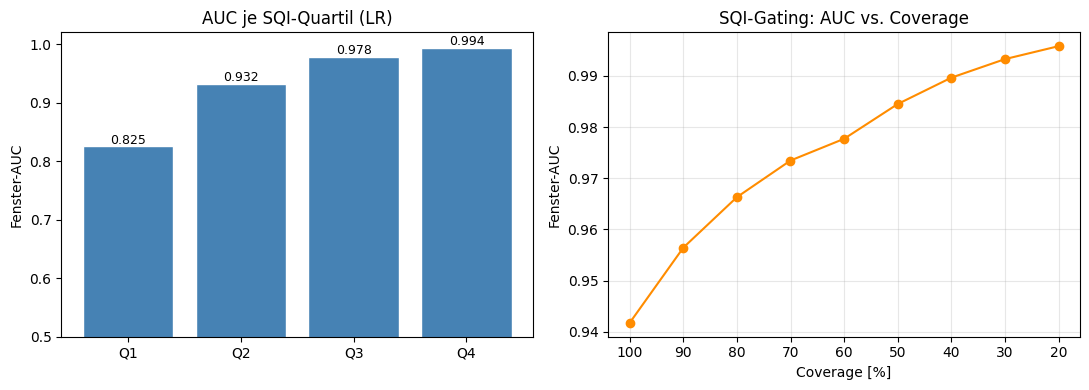

In [29]:
# === Fenster-SQI-Analyse: trennt der SQI zuverlässige von unzuverlässigen Fenstern? ===
# GT-frei. Beantwortet: lohnt der SQI auf FENSTER-Ebene (Betreuer-Fokus)?
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, accuracy_score

MODELL = 'LR'                                   # bestes Fenstermodell; frei wählbar
pipe   = M.make_pipelines(balanced=True)[MODELL]

def window_sqi_analysis(X, y, groups, w_sqi, pipe, n_bins=4):
    logo = LeaveOneGroupOut()
    yt, yp, order = [], [], []
    for tr, te in logo.split(X, y, groups):
        pipe.fit(X[tr], y[tr])
        yp.extend(pipe.predict_proba(X[te])[:, 1]); yt.extend(y[te]); order.extend(te)
    yt, yp, order = np.array(yt), np.array(yp), np.array(order)
    sqi = np.asarray(w_sqi)[order]              # SQI in Vorhersage-Reihenfolge
    yd  = (yp >= 0.5).astype(int)
    auc_all = roc_auc_score(yt, yp)
    print(f"Fenster gesamt: {len(yt)}  |  Fenster-AUC (alle): {auc_all:.3f}\n")

    edges = np.quantile(sqi, np.linspace(0, 1, n_bins + 1)); edges[-1] += 1e-9
    print("── SQI-stratifiziert (Quartile) ──")
    print(f"{'Quartil':8s}{'SQI-Bereich':22s}{'n':>7s}{'AF%':>7s}{'AUC':>8s}{'Acc':>8s}")
    strat = []
    for b in range(n_bins):
        m = (sqi >= edges[b]) & (sqi < edges[b + 1])
        if m.sum() == 0: continue
        a = roc_auc_score(yt[m], yp[m]) if len(np.unique(yt[m])) > 1 else np.nan
        strat.append((b, a, accuracy_score(yt[m], yd[m]), int(m.sum())))
        print(f"Q{b+1:<7d}[{edges[b]:.3f},{edges[b+1]:.3f}){m.sum():7d}"
              f"{100*yt[m].mean():7.0f}{a:8.3f}{accuracy_score(yt[m], yd[m]):8.3f}")

    print("\n── SQI-Gating (nur Fenster mit SQI >= Schwelle) ──")
    print(f"{'Schwelle':>9s}{'Coverage':>10s}{'n':>7s}{'AUC':>8s}")
    curve = []
    for q in np.linspace(0, 0.8, 9):
        t = np.quantile(sqi, q); m = sqi >= t
        if m.sum() < 10 or len(np.unique(yt[m])) < 2: continue
        a = roc_auc_score(yt[m], yp[m]); curve.append((t, m.mean(), int(m.sum()), a))
        print(f"{t:9.3f}{100*m.mean():9.0f}%{m.sum():7d}{a:8.3f}")

    if len(strat) >= 2 and not np.isnan(strat[0][1]) and not np.isnan(strat[-1][1]):
        d = strat[-1][1] - strat[0][1]
        print(f"\nVerdikt: AUC niedrigstes Quartil {strat[0][1]:.3f} -> höchstes "
              f"{strat[-1][1]:.3f}  (Δ={d:+.3f})")
        print("  -> SQI trennt zuverlässige von unzuverlässigen Fenstern." if d > 0.02
              else "  -> SQI trennt Fenster-Zuverlässigkeit kaum (gleichmäßige Qualität).")
    return strat, curve

strat, curve = window_sqi_analysis(X_sel, y, groups, w_sqi, pipe)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
qs = [f"Q{b+1}" for b, _, _, _ in strat]; aucs = [v for _, v, _, _ in strat]
a1.bar(qs, aucs, color='steelblue', edgecolor='white'); a1.set_ylim(0.5, 1.02)
a1.set_ylabel('Fenster-AUC'); a1.set_title(f'AUC je SQI-Quartil ({MODELL})')
for i, v in enumerate(aucs):
    if not np.isnan(v): a1.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
cov = [100*c for _, c, _, _ in curve]; ca = [v for _, _, _, v in curve]
a2.plot(cov, ca, 'o-', color='darkorange'); a2.invert_xaxis()
a2.set_xlabel('Coverage [%]'); a2.set_ylabel('Fenster-AUC')
a2.set_title('SQI-Gating: AUC vs. Coverage'); a2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR+'plot_window_sqi.png', dpi=150, bbox_inches='tight'); plt.show()

In [30]:
# === Konfundierungs-Check: misst der SQI Qualität oder heimlich den Rhythmus? ===
from sklearn.metrics import roc_auc_score
auc_sqi_af = roc_auc_score(y, w_sqi)                       # SQI ALLEIN -> AF?
print(f"SQI->AF AUC (allein): {auc_sqi_af:.3f}   "
      f"(median SQI  AF={np.median(w_sqi[y==1]):.3f}  nonAF={np.median(w_sqi[y==0]):.3f})")
print("  -> SQI ist rhythmus-agnostisch (Qualität, kein AF-Proxy)" if abs(auc_sqi_af-0.5) < 0.06
      else "  -> SQI kodiert teils den Rhythmus -> Quartil-Ergebnis konfundiert")

SQI->AF AUC (allein): 0.510   (median SQI  AF=0.771  nonAF=0.766)
  -> SQI ist rhythmus-agnostisch (Qualität, kein AF-Proxy)


# Analyse + Grafiken

In [31]:
# G0 · Setup (EINMAL — ersetzt cells 43/41-make_lr/48-spw)
%load_ext autoreload
%autoreload 2
import audit_plots as A
make_lr = lambda: M.make_pipelines(balanced=True)['LR']        # bestes Fenstermodell
spw = max(1, int((1-y).sum())) / max(1, int(y.sum()))

In [32]:
# G1 · Konsolidierte Tabelle + Cluster-CI (EINZIGE Tabellen-Quelle, ersetzt 24 und 48-Tabelle)
tab = A.results_table_with_ci(A.make_pipelines_with_mlp, X_sel, y, groups,
        models=A.MODEL_ORDER_MLP,                              # alle + MLP; für schnell: ['LR','SVM','MLP']
        modes=('window_nested', 'mv_nested', 'mv_nested_sqi'),
        window_sqi=w_sqi, n_boot=2000, scale_pos_weight=spw, n_jobs=-1)
print(tab[['Modell','Modus','AUC','AUC_CI','Sens','Sens_CI','Spez','Spez_CI']].to_string(index=False))
tab.to_csv(RESULTS_DIR+'ergebnistabelle_ci.csv', index=False)
with open(RESULTS_DIR+'ergebnistabelle_ci.tex','w') as f: f.write(tab.attrs['latex'])

Modell         Modus   AUC         AUC_CI  Sens        Sens_CI  Spez        Spez_CI
   SVM window_nested 0.929 [0.870, 0.974] 0.891 [0.779, 0.955] 0.824 [0.706, 0.911]
   SVM     mv_nested 0.970 [0.917, 1.000] 0.895 [0.733, 1.000] 0.905 [0.762, 1.000]
   SVM mv_nested_sqi 0.970 [0.917, 1.000] 0.947 [0.818, 1.000] 0.905 [0.762, 1.000]
    LR window_nested 0.942 [0.891, 0.978] 0.924 [0.859, 0.973] 0.783 [0.683, 0.902]
    LR     mv_nested 0.975 [0.928, 1.000] 1.000 [1.000, 1.000] 0.857 [0.684, 1.000]
    LR mv_nested_sqi 0.975 [0.928, 1.000] 1.000 [1.000, 1.000] 0.857 [0.684, 1.000]
    RF window_nested 0.875 [0.772, 0.949] 0.760 [0.605, 0.910] 0.785 [0.686, 0.909]
    RF     mv_nested 0.910 [0.803, 0.984] 0.789 [0.600, 0.950] 0.905 [0.762, 1.000]
    RF mv_nested_sqi 0.910 [0.803, 0.984] 0.789 [0.600, 0.950] 0.857 [0.688, 1.000]
    GB window_nested 0.864 [0.763, 0.942] 0.756 [0.596, 0.906] 0.759 [0.687, 0.911]
    GB     mv_nested 0.900 [0.786, 0.980] 0.737 [0.526, 0.933] 0.857 [0.696,

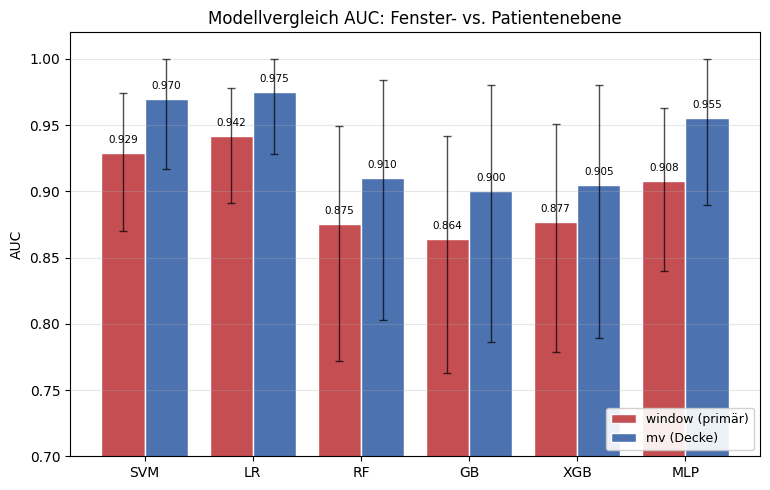

In [33]:
# G2 · Modellvergleich-Balken window vs mv (nutzt tab aus G1 — ersetzt 45 und 48-Plot)
A.plot_model_comparison_bars(tab, metric='AUC', modes=('window_nested','mv_nested'),
    save_path=RESULTS_DIR+'plot_model_comparison_window_mv.png'); plt.show()

patient  AF  n_windows  accuracy  median_prob
 PAT042   0        119  0.058824     0.854960
 PAT003   0         87  0.183908     0.710469
 PAT006   0        119  0.235294     0.486083
 PAT008   0        119  0.445378     0.174802
 PAT010   0        119  0.613445     0.127291
 PAT036   1        119  0.655462     0.392164


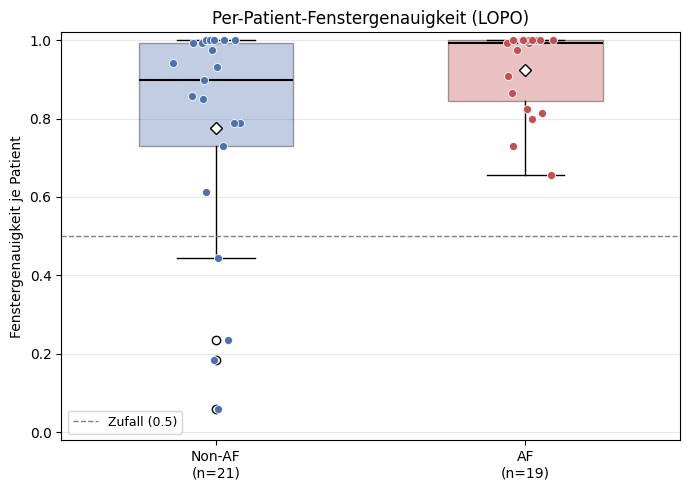

In [34]:
# G3 · Per-Patient-Fenstergenauigkeit
df_pp = A.per_patient_window_metrics(make_lr, X_sel, y, groups, nested=True, n_jobs=-1)
print(df_pp.nsmallest(6,'accuracy').to_string(index=False))
df_pp.to_csv(RESULTS_DIR+'per_patient_acc.csv', index=False)
A.plot_per_patient_accuracy(df_pp, save_path=RESULTS_DIR+'plot_per_patient_acc.png'); plt.show()

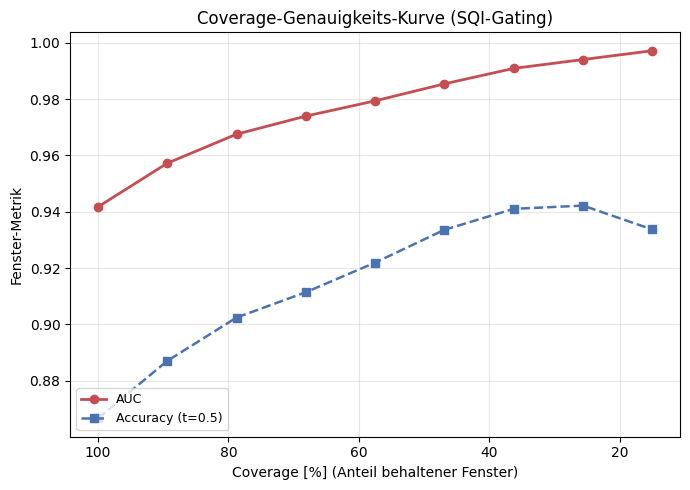

In [35]:
# G4 · Gating-Kurve
cur = A.gating_curve_from_oof(make_lr, X_sel, y, groups, w_sqi, n_points=9, n_jobs=-1)
cur.to_csv(RESULTS_DIR+'gating_curve.csv', index=False)
A.plot_gating_curve(cur, save_path=RESULTS_DIR+'plot_gating_curve.png'); plt.show()

Fenster-Panel : LR  (bestes window_nested nach AUC)
Patient-Panel : LR  (bestes mv_nested nach AUC)


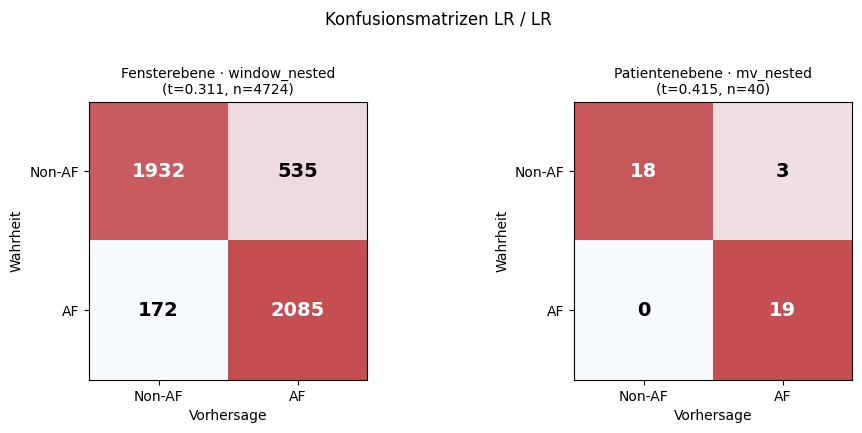

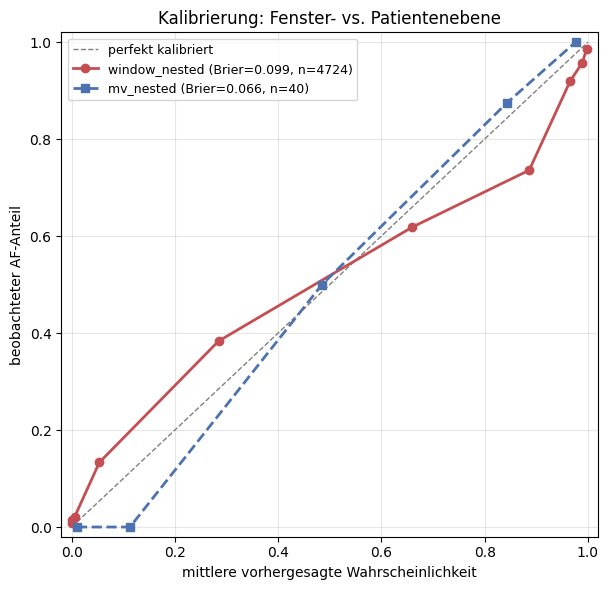

In [36]:
# G5 · Konfusionsmatrizen — datengetrieben: bestes Modell JE Modus (nicht mehr fix LR)
#   Fenster-Panel   -> bestes window_nested-Modell
#   Patienten-Panel -> bestes mv_nested-Modell
# Hinweis: nach AUC ist window_nested knapp LR (0.948 vs SVM 0.945),
# nach Accuracy/Spezifität ist es SVM — daher explizit gemacht statt hartkodiert.
CM_SELECT_METRIC = 'AUC'    # 'AUC' | 'Accuracy' | 'Spezifität' | 'Sensitivität'

def _best_for(modus):
    sub = res[res.Modus == modus].sort_values(CM_SELECT_METRIC, ascending=False)
    return sub.iloc[0]['Modell']

win_best = _best_for('window_nested')
mv_best  = _best_for('mv_nested')
print(f"Fenster-Panel : {win_best}  (bestes window_nested nach {CM_SELECT_METRIC})")
print(f"Patient-Panel : {mv_best}  (bestes mv_nested nach {CM_SELECT_METRIC})")

mk_win = lambda: M.make_pipelines(balanced=True, scale_pos_weight=spw)[win_best]
mk_mv  = lambda: M.make_pipelines(balanced=True, scale_pos_weight=spw)[mv_best]

# Fenster-Panel vom fenster-besten, Patienten-Panel vom mv-besten Modell.
cmd_w = A.confusion_window_and_mv(mk_win, X_sel, y, groups, window_sqi=w_sqi, n_jobs=-1)
cmd_m = (cmd_w if mv_best == win_best
         else A.confusion_window_and_mv(mk_mv, X_sel, y, groups, window_sqi=w_sqi, n_jobs=-1))
cmd = {'window': cmd_w['window'], 'mv': cmd_m['mv'],
       'thr_window': cmd_w['thr_window'], 'thr_mv': cmd_m['thr_mv']}
A.plot_confusion_window_and_mv(cmd, model_name=f'{win_best} / {mv_best}',
                               save_path=RESULTS_DIR+'plot_confusion_window_mv.png'); plt.show()

# Kalibrierung bleibt am fenster-besten Modell.
cal = A.calibration_window_and_mv(mk_win, X_sel, y, groups, window_sqi=w_sqi, n_jobs=-1)
A.plot_calibration_window_and_mv(cal, save_path=RESULTS_DIR+'plot_calibration_window_mv.png'); plt.show()

composite (0.5/0.3/0.2)          AUC@100%=0.942  AUC@~30%=0.997
pSQI allein (Li 2008)            AUC@100%=0.942  AUC@~30%=0.990
tSQI allein (Orphanidou 2015)    AUC@100%=0.942  AUC@~30%=0.989
bSQI allein (Behar 2013)         AUC@100%=0.942  AUC@~30%=0.986
Gleichgewicht t+p+b              AUC@100%=0.942  AUC@~30%=0.996


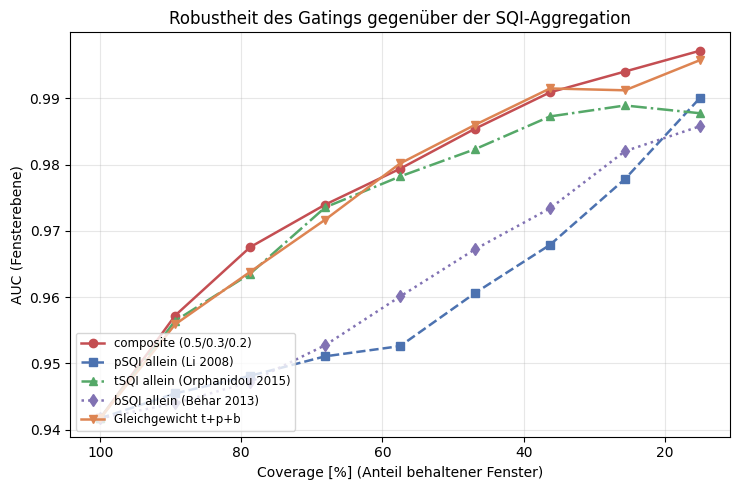

In [37]:
# G7 · Beweist: die Composite-Gewichte (0.5/0.3/0.2) sind nicht tragend
curves = A.gating_robustness(make_lr, X_sel, y, groups, df, SIGNALS, n_points=9, n_jobs=-1)
for name, cur in curves.items():
    print(f'{name:32s} AUC@100%={cur.AUC.iloc[0]:.3f}  AUC@~30%={cur[cur.coverage<=0.35].AUC.max():.3f}')
A.plot_gating_robustness(curves, save_path=RESULTS_DIR+'plot_gating_robustness.png'); plt.show()

                          Konfiguration Modell   AUC         AUC_CI  Sens  Spez
                Fenster (window_nested)     LR 0.942 [0.891, 0.978] 0.924 0.783
Patient · SQI-gewichtet (mv_nested_sqi)     LR 0.975 [0.928, 1.000] 1.000 0.857
                    Patient (mv_nested)     LR 0.975 [0.928, 1.000] 1.000 0.857
    Fenster · SQI-gated (~83% Coverage)     LR 0.962              —   NaN   NaN


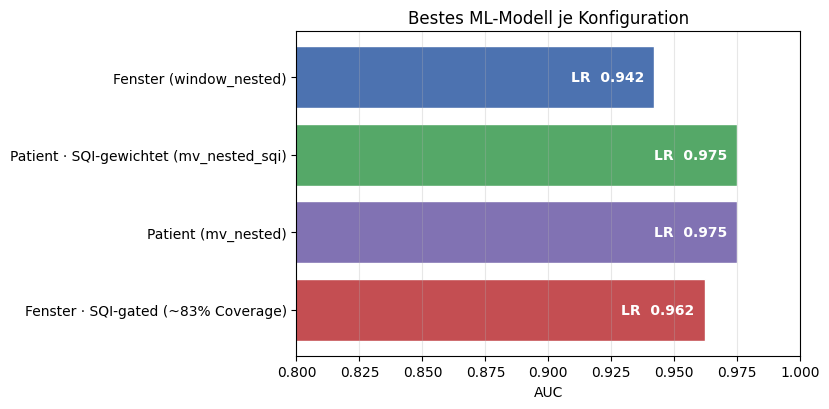

In [38]:
# G8 · Gesamtüberblick: bestes Modell je Konfiguration
#      (window_nested · SQI-gewichtet · SQI-gated · mv_nested)
# Datengetrieben aus `tab` (G1, inkl. CI) + frischer Gating-Kurve des fenster-besten Modells.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

SUMMARY_METRIC = 'AUC'   # Auswahl- und Plotmetrik

def _winner(modus):
    sub = tab[tab.Modus == modus]
    return sub.sort_values(SUMMARY_METRIC, ascending=False).iloc[0]

labels = {'window_nested': 'Fenster (window_nested)',
          'mv_nested_sqi': 'Patient · SQI-gewichtet (mv_nested_sqi)',
          'mv_nested':     'Patient (mv_nested)'}

rows = []
for modus in ['window_nested', 'mv_nested_sqi', 'mv_nested']:
    if modus not in set(tab.Modus):
        continue
    w = _winner(modus)
    rows.append({'Konfiguration': labels[modus], 'Modell': w['Modell'],
                 'AUC': w['AUC'], 'AUC_CI': w['AUC_CI'],
                 'Sens': w['Sens'], 'Spez': w['Spez']})

# SQI-Gating: fenster-bestes Modell, AUC bei der Coverage nahe 80 %
win_best = _winner('window_nested')['Modell']
mk_win = lambda: M.make_pipelines(balanced=True, scale_pos_weight=spw)[win_best]
gcur = A.gating_curve_from_oof(mk_win, X_sel, y, groups, w_sqi, n_points=11, n_jobs=-1)
gp = gcur.iloc[(gcur['coverage'] - 0.80).abs().idxmin()]
rows.append({'Konfiguration': f"Fenster · SQI-gated (~{gp['coverage']*100:.0f}% Coverage)",
             'Modell': win_best, 'AUC': round(float(gp['AUC']), 3),
             'AUC_CI': '—', 'Sens': np.nan, 'Spez': np.nan})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR + 'uebersicht_bestmodell.csv', index=False)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
yy = np.arange(len(summary))[::-1]
cols = ['#4C72B0', '#55A868', '#8172B3', '#C44E52'][:len(summary)]
ax.barh(yy, summary['AUC'].values, color=cols, edgecolor='white')
ax.set_yticks(yy); ax.set_yticklabels(summary['Konfiguration'])
for y_, v, mdl in zip(yy, summary['AUC'].values, summary['Modell'].values):
    ax.text(v - 0.004, y_, f"{mdl}  {v:.3f}", va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)
ax.set_xlim(0.80, 1.0); ax.set_xlabel('AUC')
ax.set_title('Bestes ML-Modell je Konfiguration')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'plot_uebersicht_bestmodell.png', dpi=150, bbox_inches='tight')
plt.show()

# Betreuertermin — Agenda & Ergebnis-Briefing
*AF-Detektion in kontaktlosen Signalen · Betreuer N. Blaß · window_nested = primär, mv_nested = Decke*

---

## 1 · Headline (eine Folie)

**Primär (Fensterebene, 30 s, deployment-relevant):** LR **AUC 0.948** [0.902, 0.980], SVM 0.945 [0.895, 0.981].
**Decke (Patientenebene, 30 min):** SVM **0.980** [0.940, 1.000], LR 0.977.
Cluster-Bootstrap-CI (Patienten-Resampling), LOPO-CV, n = 40 (19 AF / 21 Non-AF).

| Modus | Bestes Modell | AUC | Sens | Spez |
|---|---|---|---|---|
| window_nested *(primär)* | LR | 0.948 | 0.936 | 0.770 |
| mv_nested *(Decke)* | SVM | 0.980 | 0.947 | 0.857 |

---

## 2 · Drei ehrliche Befunde (aktiv vortragen, nicht abwarten)

**A — Lineare Modelle als Tier, kein NN nötig.** LR/SVM (0.945–0.948) > RF/GB/XGB (0.89–0.92) > MLP (0.918) am Fenster. CIs überlappen → **Tier, kein Ranking**. Merkmalsraum linear trennbar; Komplexität hilft nicht. Belegt die Methodenwahl (klassisches ML, kein Optuna/NN).

**B — Fusion schlägt PPG nicht.** PPG allein 0.982 ≈ Fusion 0.980; cECG 0.905; BCG allein 0.812 (Sens 0.47). Die kontaktlosen Zusatzmodalitäten liefern **Robustheit/Redundanz, keine AUC**. PPG trägt das Signal. (Offensiv framen — nicht überverkaufen.)

**C — SQI wirkt über Gating, nicht über Fusion.** mv_nested_sqi ≈ mv_nested (kein Fusionsgewinn). Wert des SQI: Fenster-Gating als Coverage-Genauigkeits-Kompromiss — 100 %→0.948, 50 %→0.989, 20 %→0.997 (Q1 0.836 → Q4 0.996). Nicht-zirkulär, weil SQI rhythmus-agnostisch: **SQI→AF AUC 0.510**.

---

## 3 · Wo das Modell ringt (Diskussionspunkt)

Per-Patient-Fenstergenauigkeit: **Sensitivität gleichverteilt, Spezifität von ~5 Non-AF-Patienten getragen.**
Schlechteste: PAT042 (Acc 0.05, median_prob 0.816 → *selbstbewusst falsch*), PAT006, PAT003, PAT010, PAT008 — alle Non-AF.
→ Vermutung: andere Arrhythmie oder persistentes Artefakt. **567 Fenster-FPs** konzentriert auf diese Patienten.

---

## 4 · Drei Entscheidungen, die ich von dir brauche

1. **Framing & Gliederung absegnen:** window_nested primär, mv_nested als Decke, pooled nur fürs Leckage-Argument. Passt die Kapitelstruktur (3.7 Eval, 4.2 Ergebnisse, 5.2 Diskussion)?
2. **FP-Patienten:** Sind PAT042 & Co. als andere Arrhythmie / schlechte Signalqualität bekannt? Das verknüpft Per-Patient → SQI → Gating zu einer Erzählung — und erklärt die Spezifitäts-Schwäche sauber.
3. **bSQI:** zwei Detektor-*Konfigurationen* ehrlich framen (Behar 2013 fürs Konzept zitieren) — oder 2-Zeilen-Swap auf zwei wirklich unabhängige Detektoren (Amplitude vs. CWT)?

---

## 5 · Vorbereitete Antworten (falls Blaß nachhakt)

- **Feature-Selektions-Leckage:** RF-Selektion lief global; empirisch gemessene Optimismus-Schranke **ΔAUC ≤ 0.006** (global vs. pro Fold genested). Nicht ergebnistragend.
- **SQI-Composite-Gewichte (0.5/0.3/0.2):** heuristisch, aber **nicht tragend** — Gating-Kurve invariant gegenüber Aggregation (composite/pSQI/tSQI/Gleichgewicht: ΔAUC ≈ 0.008).
- **Kleines n / Scope:** n=40 → Tier statt Ranking, weite CIs. AF = persistentes, patientenkonstantes Label → jedes 30-s-Fenster repräsentativ. Paroxysmales AF explizit als schwereres, nicht adressiertes Problem abgegrenzt.
- **Kalibrierung:** Brier window 0.094 / mv 0.060 (mv nahezu perfekt, window an den Rändern leicht überkonfident).

---

*Mitbringen: Tabelle (Modell × Modus + CI), Modellvergleich-Balken, Per-Patient-Boxplot, Gating-Kurve, Konfusionsmatrizen, Kalibrierung, SQI-Robustheit.*
